# Tenxnet Recipe SPARK validation-loss curves

Compare validation loss from the `100`, `200`, `500`, and `700` runs. Each curve is read directly from the run's `log.txt`. If training was restarted and an epoch appears more than once, the last logged value is used.

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# This works when Jupyter starts in pytorch_seg or its parent directory.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "runs").is_dir():
    PROJECT_ROOT = PROJECT_ROOT / "pytorch_seg"
if not (PROJECT_ROOT / "runs").is_dir():
    raise FileNotFoundError("Could not locate the pytorch_seg/runs directory")

RUN_SUFFIXES = (100, 200, 500, 700)
RUN_PREFIX = "tenxnet_recipe_spark_unfrozen_normal_cell"
RUN_DIRS = {
    suffix: PROJECT_ROOT / "runs" / f"{RUN_PREFIX}_{suffix}"
    for suffix in RUN_SUFFIXES
}


def load_val_curve(log_path):
    """Return sorted epochs/losses; the last record wins for duplicate epochs."""
    records_by_epoch = {}
    duplicate_count = 0
    with log_path.open() as handle:
        for line_number, line in enumerate(handle, start=1):
            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                continue
            if "epoch" not in record or "val_loss" not in record:
                continue
            epoch = int(record["epoch"])
            if epoch in records_by_epoch:
                duplicate_count += 1
            records_by_epoch[epoch] = (float(record["val_loss"]), line_number)

    if not records_by_epoch:
        raise ValueError(f"No epoch-level val_loss records found in {log_path}")
    epochs = np.array(sorted(records_by_epoch), dtype=int)
    losses = np.array([records_by_epoch[e][0] for e in epochs], dtype=float)
    return epochs, losses, duplicate_count


curves = {}
for suffix, run_dir in RUN_DIRS.items():
    log_path = run_dir / "log.txt"
    epochs, losses, duplicate_count = load_val_curve(log_path)
    curves[suffix] = (epochs, losses)
    best_index = int(np.argmin(losses))
    print(
        f"{suffix}: {len(epochs)} epochs, "
        f"best val_loss={losses[best_index]:.6f} at epoch {epochs[best_index]}, "
        f"duplicate records replaced={duplicate_count}"
    )

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/home/ruizhi.yuan/pytorch_seg/runs/tenxnet_recipe_spark_unfrozen_normal_cell_100/log.txt'

/tmp/ipykernel_614231/277059734.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Run suffix", frameon=True)


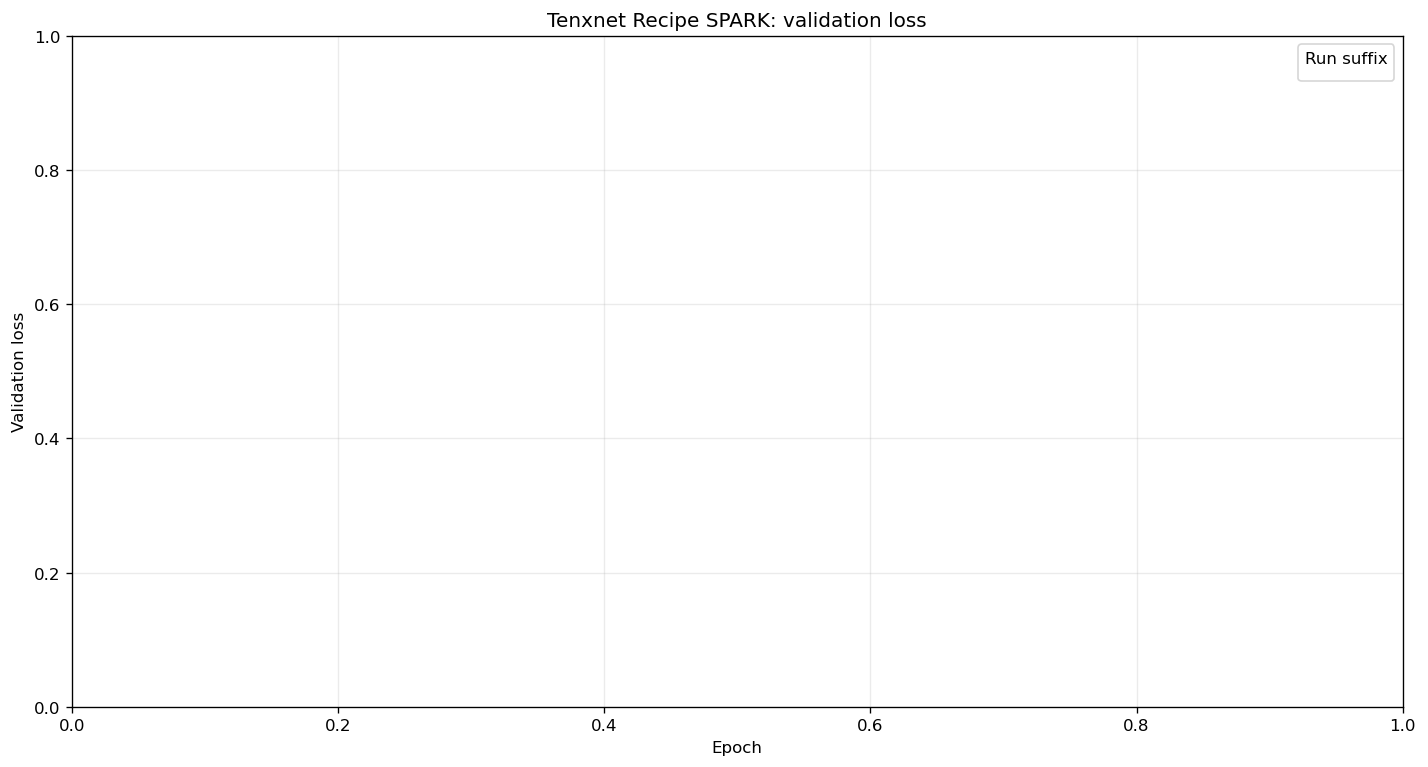

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6.5), dpi=120)
colors = plt.cm.tab10(np.arange(len(curves)))

for color, (suffix, (epochs, losses)) in zip(colors, curves.items()):
    best_index = int(np.argmin(losses))
    best_epoch = int(epochs[best_index])
    best_loss = float(losses[best_index])
    ax.plot(
        epochs, losses, color=color, linewidth=1.6, alpha=0.9,
        label=f"{suffix}: best {best_loss:.4f} @ epoch {best_epoch}",
    )
    ax.scatter(best_epoch, best_loss, color=color, s=38, zorder=3)

ax.set_title("Tenxnet Recipe SPARK: validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation loss")
ax.grid(True, alpha=0.25)
ax.legend(title="Run suffix", frameon=True)
fig.tight_layout()
plt.show()

## Instance F1 comparison

The middle table column is intentionally omitted; this chart uses only the model names and reported F1 values.

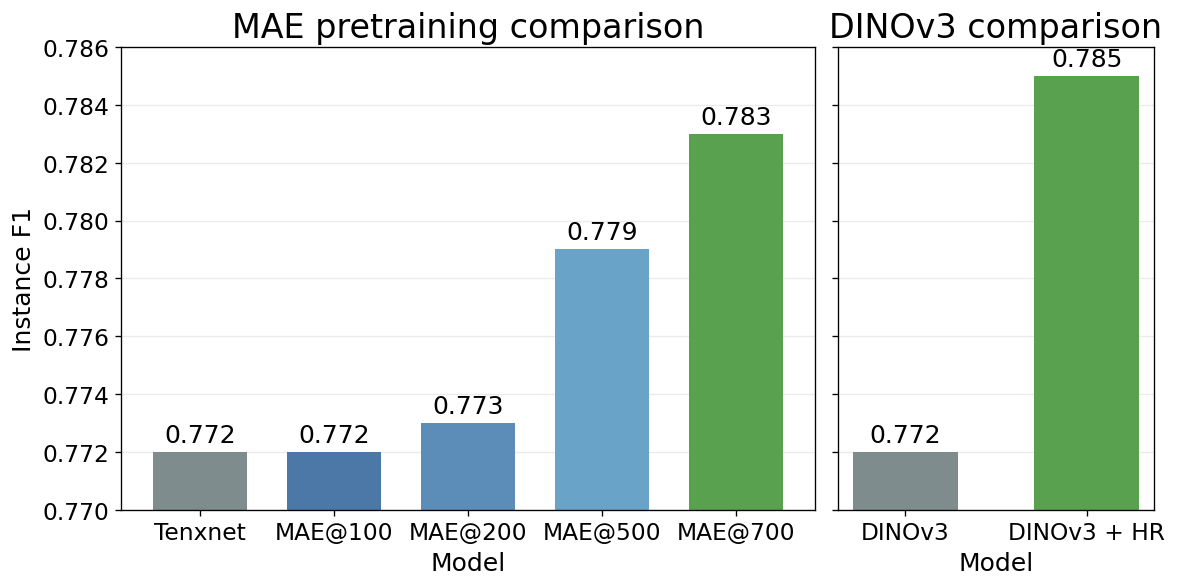

In [ ]:
f1_labels = ["Tenxnet", "MAE@100", "MAE@200", "MAE@500", "MAE@700"]
f1_values = np.array([0.772, 0.772, 0.773, 0.779, 0.783])

dino_labels = ["DINOv3", "DINOv3 + HR"]
dino_f1_values = np.array([0.772, 0.785])

fig, (ax_spark, ax_dino) = plt.subplots(
    1, 2, figsize=(10, 5), dpi=120, sharey=True,
    gridspec_kw={"width_ratios": [2.2, 1]},
)
bar_colors = ["#7f8c8d", "#4c78a8", "#5b8db8", "#69a3c8", "#59a14f"]
spark_bars = ax_spark.bar(f1_labels, f1_values, color=bar_colors, width=0.7)
ax_spark.bar_label(spark_bars, labels=[f"{value:.3f}" for value in f1_values], padding=3, fontsize=15)

dino_bars = ax_dino.bar(dino_labels, dino_f1_values, color=["#7f8c8d", "#59a14f"], width=0.58)
ax_dino.bar_label(dino_bars, labels=[f"{value:.3f}" for value in dino_f1_values], padding=3, fontsize=15)

ax_spark.set_title("MAE pretraining comparison", fontsize=20)
ax_dino.set_title("DINOv3 comparison", fontsize=20)
ax_spark.set_xlabel("Model", fontsize=15)
ax_dino.set_xlabel("Model", fontsize=15)
ax_spark.set_ylabel("Instance F1", fontsize=15)
ax_spark.set_ylim(0.77, 0.786)
for axis in (ax_spark, ax_dino):
    axis.grid(axis="y", alpha=0.25)
    axis.set_axisbelow(True)
    axis.tick_params(axis="x", labelsize=14)
    axis.tick_params(axis="y", labelsize=14)
# fig.suptitle("Instance F1 comparison", fontsize=14)
fig.tight_layout()
plt.show()

## Tenxnet and SSL F1 comparison

This view compares the Tenxnet baseline with the SSL-pretrained models and excludes the DINOv3 results.

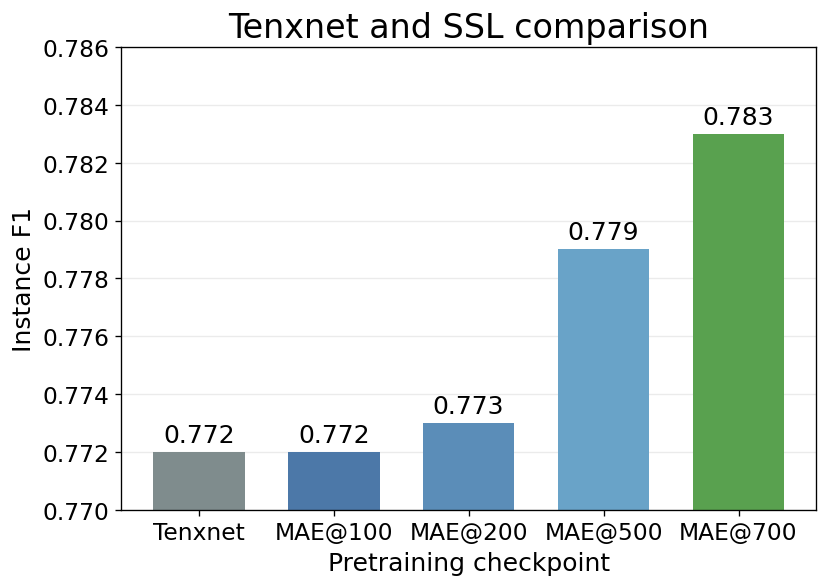

In [ ]:
tenxnet_ssl_labels = f1_labels
tenxnet_ssl_f1_values = f1_values

fig, ax_ssl_only = plt.subplots(figsize=(7, 5), dpi=120)
tenxnet_ssl_colors = ["#7f8c8d", "#4c78a8", "#5b8db8", "#69a3c8", "#59a14f"]
ssl_bars = ax_ssl_only.bar(tenxnet_ssl_labels, tenxnet_ssl_f1_values, color=tenxnet_ssl_colors, width=0.68)
ax_ssl_only.bar_label(
    ssl_bars,
    labels=[f"{value:.3f}" for value in tenxnet_ssl_f1_values],
    padding=3,
    fontsize=15,
)

ax_ssl_only.set_title("Tenxnet and SSL comparison", fontsize=20)
ax_ssl_only.set_xlabel("Pretraining checkpoint", fontsize=15)
ax_ssl_only.set_ylabel("Instance F1", fontsize=15)
ax_ssl_only.set_ylim(0.77, 0.786)
ax_ssl_only.grid(axis="y", alpha=0.25)
ax_ssl_only.set_axisbelow(True)
ax_ssl_only.tick_params(axis="x", labelsize=14)
ax_ssl_only.tick_params(axis="y", labelsize=14)
fig.tight_layout()
plt.show()

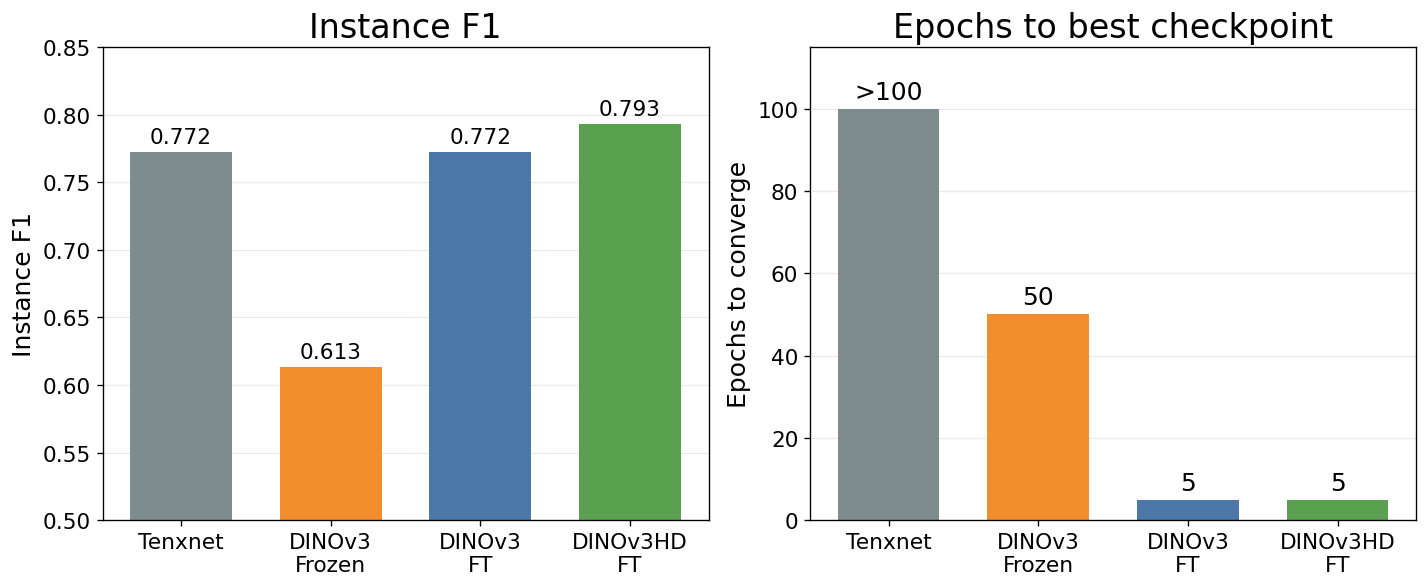

In [ ]:
comparison_labels = ["Tenxnet", "DINOv3\nFrozen", "DINOv3\nFT", "DINOv3HD\nFT"]
comparison_f1 = np.array([0.772, 0.613, 0.772, 0.793])
# Tenxnet is plotted at 100 only as a lower bound and labeled >100.
convergence_epochs_plot = np.array([100, 50, 5, 5])
convergence_labels = [">100", "50", "5", "5"]
comparison_colors = ["#7f8c8d", "#f28e2b", "#4c78a8", "#59a14f"]

fig, (ax_f1, ax_epochs) = plt.subplots(1, 2, figsize=(12, 5), dpi=120)

f1_bars = ax_f1.bar(comparison_labels, comparison_f1, color=comparison_colors, width=0.68)
ax_f1.bar_label(f1_bars, labels=[f"{value:.3f}" for value in comparison_f1], padding=3, fontsize=13)
ax_f1.set_title("Instance F1", fontsize=20)
ax_f1.set_ylabel("Instance F1", fontsize=15)
ax_f1.set_ylim(0.5, 0.85)

epoch_bars = ax_epochs.bar(comparison_labels, convergence_epochs_plot, color=comparison_colors, width=0.68)
ax_epochs.bar_label(epoch_bars, labels=convergence_labels, padding=3, fontsize=15)
ax_epochs.set_title("Epochs to best checkpoint", fontsize=20)
ax_epochs.set_ylabel("Epochs to converge", fontsize=15)
ax_epochs.set_ylim(0, 115)

for axis in (ax_f1, ax_epochs):
    axis.grid(axis="y", alpha=0.25)
    axis.set_axisbelow(True)
    axis.tick_params(axis="x", labelsize=13)
    axis.tick_params(axis="y", labelsize=13)

fig.tight_layout()
plt.show()

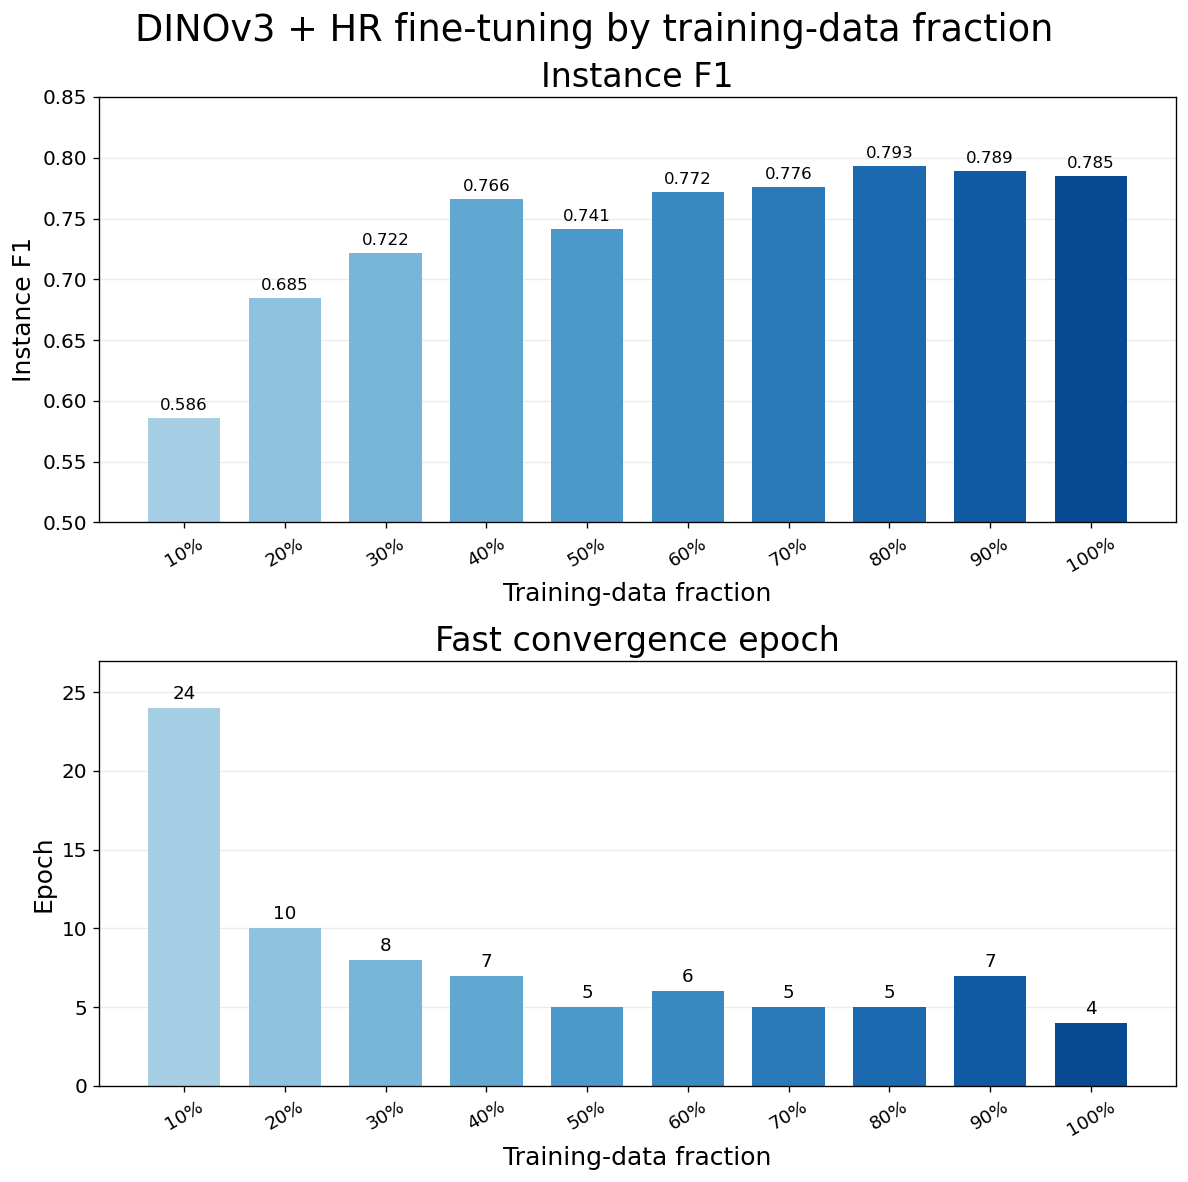

In [ ]:
training_data_labels = ["10%", "20%", "30%", "40%", "50%", "60%", "70%", "80%", "90%", "100%"]
training_data_f1 = np.array([0.586, 0.685, 0.722, 0.766, 0.741, 0.772, 0.776, 0.793, 0.789, 0.785])
fast_convergence_epochs = np.array([24, 10, 8, 7, 5, 6, 5, 5, 7, 4])
# The 10% setting corresponds to 600 training samples.

data_fraction_colors = plt.cm.Blues(np.linspace(0.35, 0.9, len(training_data_labels)))
fig, (ax_data_f1, ax_data_epochs) = plt.subplots(2, 1, figsize=(10, 10), dpi=120)

data_f1_bars = ax_data_f1.bar(training_data_labels, training_data_f1, color=data_fraction_colors, width=0.72)
ax_data_f1.bar_label(
    data_f1_bars,
    labels=[f"{value:.3f}" for value in training_data_f1],
    padding=3,
    fontsize=10,
)
ax_data_f1.set_title("Instance F1", fontsize=20)
ax_data_f1.set_xlabel("Training-data fraction", fontsize=15)
ax_data_f1.set_ylabel("Instance F1", fontsize=15)
ax_data_f1.set_ylim(0.5, 0.85)

data_epoch_bars = ax_data_epochs.bar(training_data_labels, fast_convergence_epochs, color=data_fraction_colors, width=0.72)
ax_data_epochs.bar_label(data_epoch_bars, padding=3, fontsize=11)
ax_data_epochs.set_title("Fast convergence epoch", fontsize=20)
ax_data_epochs.set_xlabel("Training-data fraction", fontsize=15)
ax_data_epochs.set_ylabel("Epoch", fontsize=15)
ax_data_epochs.set_ylim(0, 27)

for axis in (ax_data_f1, ax_data_epochs):
    axis.grid(axis="y", alpha=0.25)
    axis.set_axisbelow(True)
    axis.tick_params(axis="x", labelsize=11, rotation=30)
    axis.tick_params(axis="y", labelsize=12)

fig.suptitle("DINOv3 + HR fine-tuning by training-data fraction", fontsize=22)
fig.tight_layout()
plt.show()

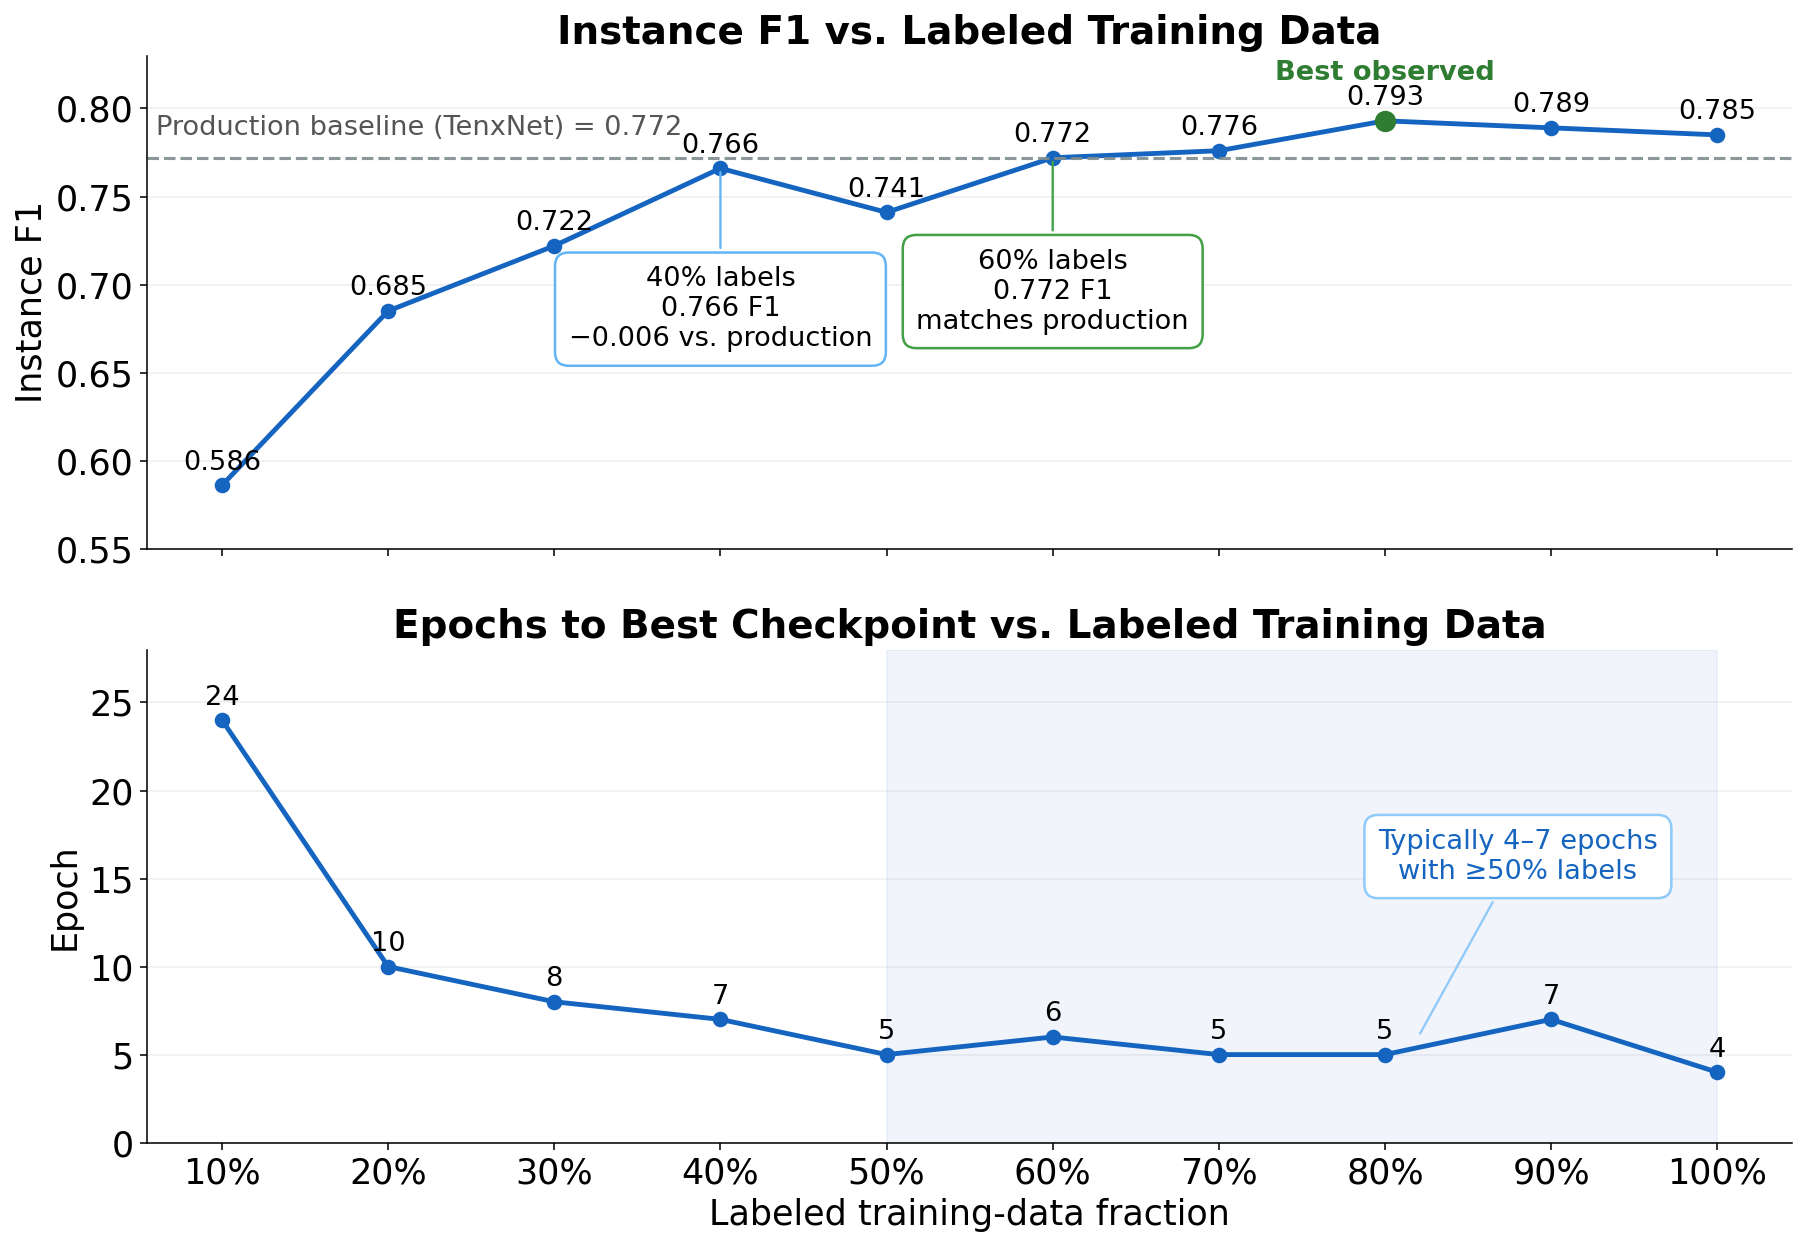

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

training_data_labels = [
    "10%", "20%", "30%", "40%", "50%",
    "60%", "70%", "80%", "90%", "100%"
]

training_fractions = np.arange(10, 101, 10)

training_data_f1 = np.array([
    0.586, 0.685, 0.722, 0.766, 0.741,
    0.772, 0.776, 0.793, 0.789, 0.785
])

fast_convergence_epochs = np.array([
    24, 10, 8, 7, 5, 6, 5, 5, 7, 4
])

production_f1 = 0.772

fig, (ax_data_f1, ax_data_epochs) = plt.subplots(
    2, 1,
    figsize=(13, 9),
    dpi=140,
    sharex=True
)

# ============================================================
# Top: Instance F1 vs. labeled training data
# ============================================================

ax_data_f1.plot(
    training_fractions,
    training_data_f1,
    marker="o",
    markersize=7,
    linewidth=2.5,
    color="#1565C0"
)

# Production baseline
ax_data_f1.axhline(
    production_f1,
    linestyle="--",
    linewidth=1.6,
    color="#7F8C8D",
    alpha=0.9
)

ax_data_f1.text(
    6,
    production_f1 + 0.013,
    "Production baseline (TenxNet) = 0.772",
    fontsize=14,
    color="#555555"
)

# Value labels
for x, y in zip(training_fractions, training_data_f1):
    ax_data_f1.annotate(
        f"{y:.3f}",
        (x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=14
    )

# 40% callout
ax_data_f1.annotate(
    "40% labels\n0.766 F1\n−0.006 vs. production",
    xy=(40, training_data_f1[3]),
    xytext=(40, 0.665),
    ha="center",
    fontsize=14,
    bbox=dict(
        boxstyle="round,pad=0.5",
        fc="white",
        ec="#64B5F6",
        lw=1.3
    ),
    arrowprops=dict(
        arrowstyle="-",
        color="#64B5F6",
        lw=1.2
    )
)

# 60% callout
ax_data_f1.annotate(
    "60% labels\n0.772 F1\nmatches production",
    xy=(60, training_data_f1[5]),
    xytext=(60, 0.675),
    ha="center",
    fontsize=14,
    bbox=dict(
        boxstyle="round,pad=0.5",
        fc="white",
        ec="#43A047",
        lw=1.3
    ),
    arrowprops=dict(
        arrowstyle="-",
        color="#43A047",
        lw=1.2
    )
)

# Best observed point
ax_data_f1.scatter(
    [80],
    [training_data_f1[7]],
    s=100,
    color="#2E7D32",
    zorder=5
)

ax_data_f1.text(
    80,
    training_data_f1[7] + 0.023,
    "Best observed",
    ha="center",
    fontsize=14,
    fontweight="bold",
    color="#2E7D32"
)

ax_data_f1.set_title(
    "Instance F1 vs. Labeled Training Data",
    fontsize=20,
    fontweight="bold"
)

ax_data_f1.set_ylabel("Instance F1", fontsize=18)
ax_data_f1.set_ylim(0.55, 0.83)


# ============================================================
# Bottom: epochs to best checkpoint
# ============================================================

ax_data_epochs.plot(
    training_fractions,
    fast_convergence_epochs,
    marker="o",
    markersize=7,
    linewidth=2.5,
    color="#1565C0"
)

# Highlight region where training is consistently fast
ax_data_epochs.axvspan(
    50, 100,
    alpha=0.06,
    color="#1565C0"
)

for x, y in zip(training_fractions, fast_convergence_epochs):
    ax_data_epochs.annotate(
        f"{y}",
        (x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=14
    )

ax_data_epochs.annotate(
    "Typically 4–7 epochs\nwith ≥50% labels",
    xy=(82, 6),
    xytext=(88, 15),
    ha="center",
    fontsize=14,
    color="#1565C0",
    bbox=dict(
        boxstyle="round,pad=0.5",
        fc="white",
        ec="#90CAF9",
        lw=1.3
    ),
    arrowprops=dict(
        arrowstyle="-",
        color="#90CAF9",
        lw=1.2
    )
)

ax_data_epochs.set_title(
    "Epochs to Best Checkpoint vs. Labeled Training Data",
    fontsize=20,
    fontweight="bold"
)

ax_data_epochs.set_xlabel(
    "Labeled training-data fraction",
    fontsize=18
)

ax_data_epochs.set_ylabel("Epoch", fontsize=18)
ax_data_epochs.set_ylim(0, 28)

ax_data_epochs.set_xticks(
    training_fractions,
    training_data_labels
)


# ============================================================
# Shared styling
# ============================================================

for ax in (ax_data_f1, ax_data_epochs):
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)

    ax.tick_params(
        axis="both",
        labelsize=18
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


fig.tight_layout(h_pad=2.0)

plt.show()

## Normal-cell and large-cell image examples

Three examples from each validation set are shown. The left column is a two-channel composite (channel 0 = green, channel 1 = magenta); the right column shows GT instances over a grayscale combination of both channels.

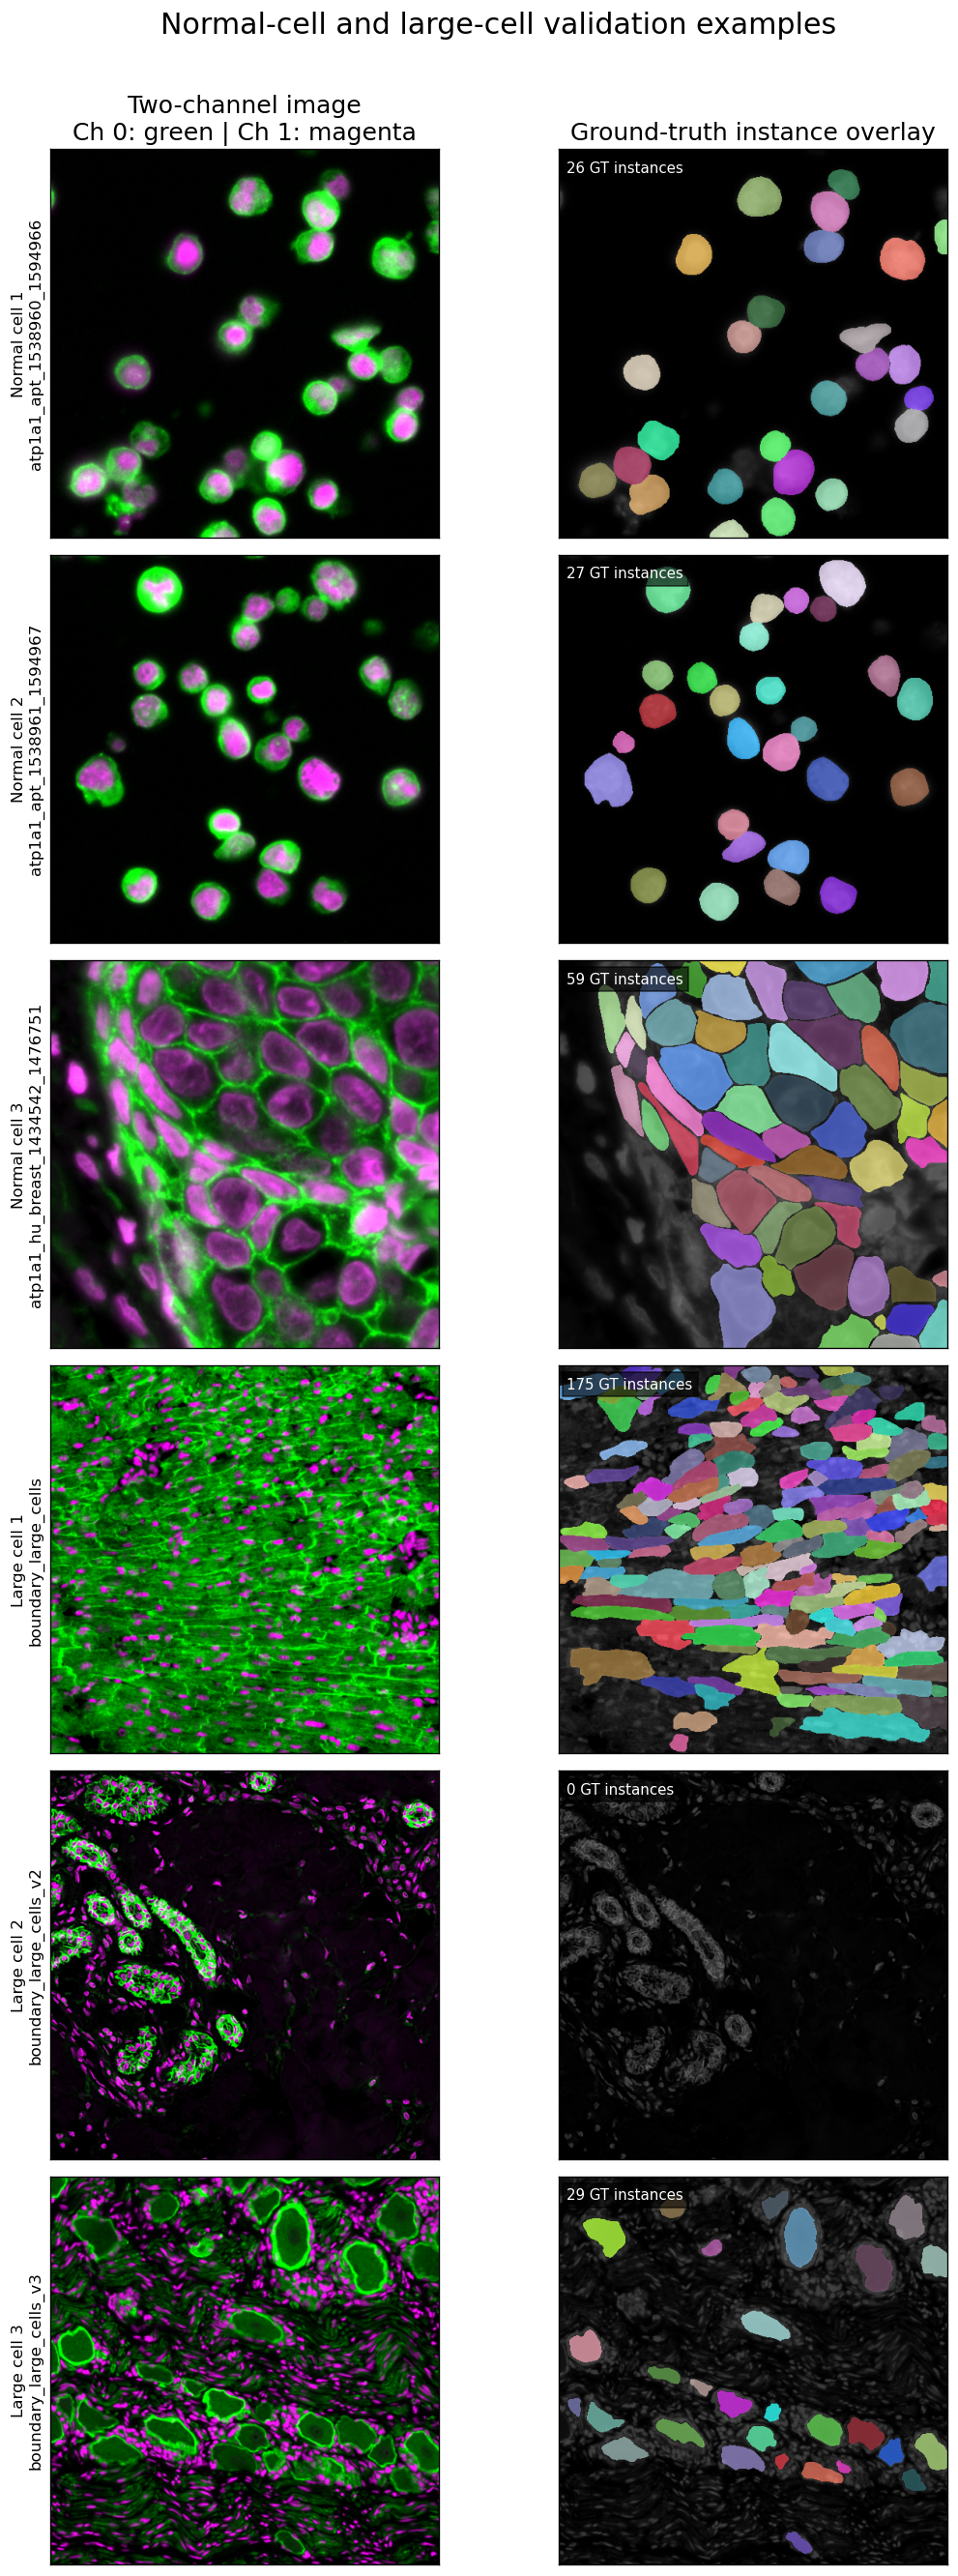

In [ ]:
import csv

import tifffile

NORMAL_CELL_MANIFEST = PROJECT_ROOT / "cache/manifest_cell_tenxnet_val.csv"
LARGE_CELL_MANIFEST = PROJECT_ROOT / "cache/manifest_val_local.csv"
N_EXAMPLES_PER_TYPE = 3


def load_available_rows(manifest_path):
    with manifest_path.open(newline="") as handle:
        rows = list(csv.DictReader(handle))
    rows = [
        row for row in rows
        if Path(row["image_path"]).is_file() and Path(row["inst_ridge_path"]).is_file()
    ]
    if not rows:
        raise FileNotFoundError(f"No readable image/GT pairs found in {manifest_path}")
    return rows


def select_diverse_examples(rows, count):
    selected = []
    selected_ids = set()
    seen_subdirs = set()
    for row in rows:
        if row["subdir"] not in seen_subdirs:
            selected.append(row)
            selected_ids.add((row["subdir"], row["base"]))
            seen_subdirs.add(row["subdir"])
            if len(selected) == count:
                return selected
    for row in rows:
        row_id = (row["subdir"], row["base"])
        if row_id not in selected_ids:
            selected.append(row)
            selected_ids.add(row_id)
            if len(selected) == count:
                break
    return selected


def normalize_channel(channel):
    channel = channel.astype(np.float32)
    lo, hi = np.percentile(channel, (1, 99))
    return np.clip((channel - lo) / (hi - lo + 1e-6), 0, 1)


def load_two_channel_view(image_path):
    image = tifffile.imread(image_path)
    if image.ndim == 3 and image.shape[-1] > 5 and image.shape[0] <= 5:
        image = np.moveaxis(image, 0, -1)
    if image.ndim != 3 or image.shape[-1] < 2:
        raise ValueError(f"Expected an H x W x 2 image, got {image.shape}: {image_path}")
    channel_0 = normalize_channel(image[..., 0])
    channel_1 = normalize_channel(image[..., 1])
    color_composite = np.stack([channel_1, channel_0, channel_1], axis=-1)
    grayscale_composite = 0.5 * (channel_0 + channel_1)
    return color_composite, grayscale_composite


def load_gt_instances(inst_ridge_path):
    inst_ridge = np.load(inst_ridge_path)
    if inst_ridge.ndim == 3:
        return inst_ridge[..., 0] if inst_ridge.shape[-1] <= 4 else inst_ridge[0]
    return inst_ridge


def make_gt_overlay(grayscale, gt, seed):
    rng = np.random.default_rng(seed)
    n_instances = int(gt.max())
    colors = np.zeros((n_instances + 1, 3), dtype=np.float32)
    if n_instances:
        colors[1:] = rng.uniform(0.15, 1.0, size=(n_instances, 3))
    background = np.repeat(grayscale[..., None], 3, axis=-1)
    overlay = 0.45 * background
    foreground = gt > 0
    overlay[foreground] = (
        0.2 * background[foreground] + 0.8 * colors[gt[foreground]]
    )
    return overlay, n_instances


normal_rows = select_diverse_examples(load_available_rows(NORMAL_CELL_MANIFEST), N_EXAMPLES_PER_TYPE)
large_rows = select_diverse_examples(load_available_rows(LARGE_CELL_MANIFEST), N_EXAMPLES_PER_TYPE)
examples = [("Normal cell", row) for row in normal_rows] + [("Large cell", row) for row in large_rows]

fig, axes = plt.subplots(len(examples), 2, figsize=(10, 3.7 * len(examples)), dpi=120)
axes[0, 0].set_title("Two-channel image\nCh 0: green | Ch 1: magenta", fontsize=15)
axes[0, 1].set_title("Ground-truth instance overlay", fontsize=15)

for row_index, (cell_type, row) in enumerate(examples):
    composite, grayscale = load_two_channel_view(row["image_path"])
    gt = load_gt_instances(row["inst_ridge_path"])
    gt_overlay, n_instances = make_gt_overlay(grayscale, gt, seed=100 + row_index)

    axes[row_index, 0].imshow(composite)
    axes[row_index, 1].imshow(gt_overlay)
    axes[row_index, 0].set_ylabel(
        f"{cell_type} {row_index % N_EXAMPLES_PER_TYPE + 1}\n{row['subdir']}",
        fontsize=10,
    )
    axes[row_index, 1].text(
        0.02, 0.97, f"{n_instances} GT instances",
        transform=axes[row_index, 1].transAxes, va="top", ha="left",
        color="white", fontsize=9,
        bbox={"facecolor": "black", "alpha": 0.6, "pad": 3},
    )
    for axis in axes[row_index]:
        axis.set_xticks([])
        axis.set_yticks([])

fig.suptitle("Normal-cell and large-cell validation examples", fontsize=18, y=0.998)
fig.tight_layout(rect=(0, 0, 1, 0.99))
plt.show()

## SSL checkpoint F1 comparison

Instance F1 across SSL checkpoints from 100 through 1000.

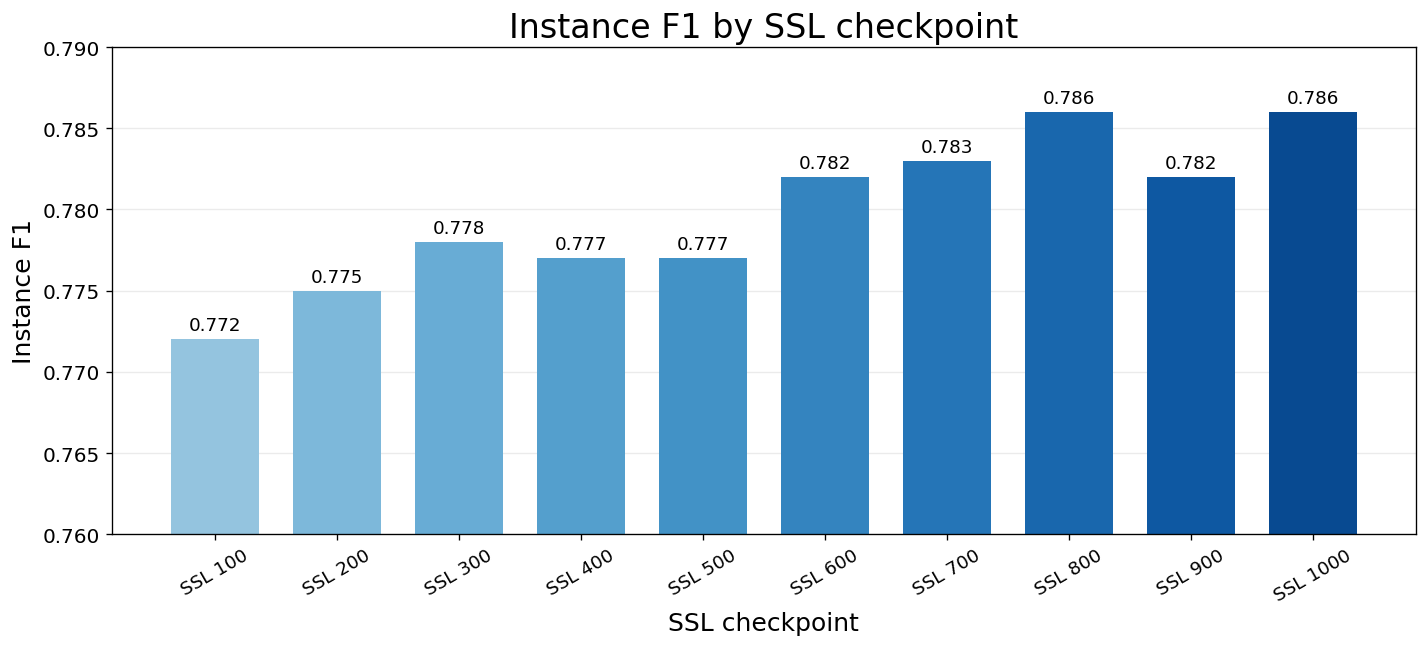

In [ ]:
ssl_checkpoint_labels = [
    "SSL 100", "SSL 200", "SSL 300", "SSL 400", "SSL 500",
    "SSL 600", "SSL 700", "SSL 800", "SSL 900", "SSL 1000",
]
ssl_checkpoint_f1 = np.array([
    0.772, 0.775, 0.778, 0.777, 0.777,
    0.782, 0.783, 0.786, 0.782, 0.786,
])

fig, ax_ssl_checkpoints = plt.subplots(figsize=(12, 5.5), dpi=120)
ssl_checkpoint_colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(ssl_checkpoint_labels)))
ssl_checkpoint_bars = ax_ssl_checkpoints.bar(
    ssl_checkpoint_labels, ssl_checkpoint_f1,
    color=ssl_checkpoint_colors, width=0.72,
)
ax_ssl_checkpoints.bar_label(
    ssl_checkpoint_bars,
    labels=[f"{value:.3f}" for value in ssl_checkpoint_f1],
    padding=3, fontsize=11,
)
ax_ssl_checkpoints.set_title("Instance F1 by SSL checkpoint", fontsize=20)
ax_ssl_checkpoints.set_xlabel("SSL checkpoint", fontsize=15)
ax_ssl_checkpoints.set_ylabel("Instance F1", fontsize=15)
ax_ssl_checkpoints.set_ylim(0.76, 0.79)
ax_ssl_checkpoints.grid(axis="y", alpha=0.25)
ax_ssl_checkpoints.set_axisbelow(True)
ax_ssl_checkpoints.tick_params(axis="x", labelsize=11, rotation=30)
ax_ssl_checkpoints.tick_params(axis="y", labelsize=12)
fig.tight_layout()
plt.show()

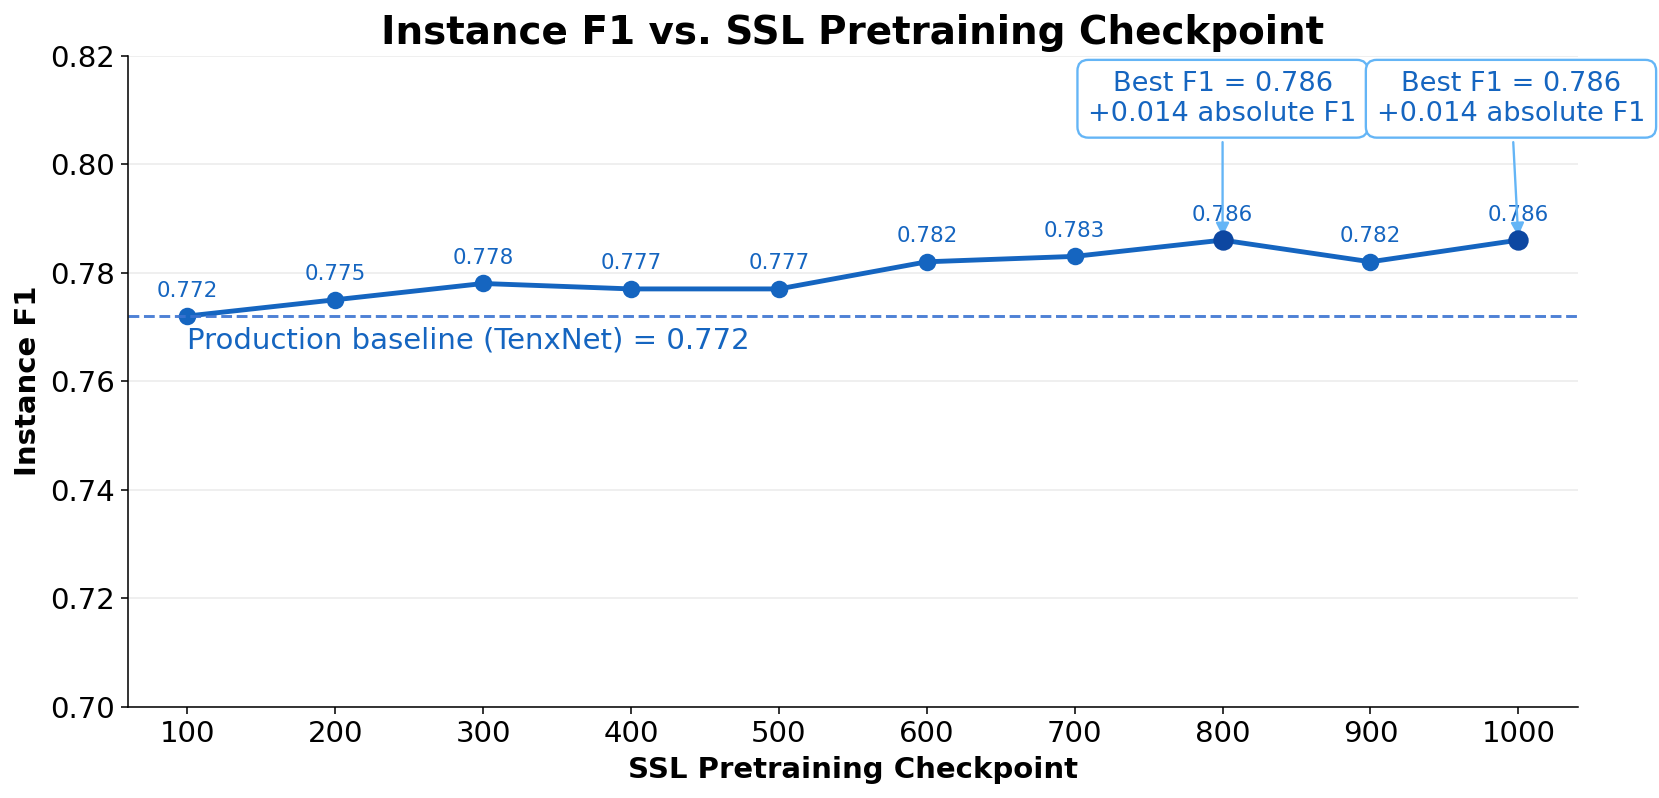

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ssl_checkpoint_labels = [
    "100", "200", "300", "400", "500",
    "600", "700", "800", "900", "1000",
]

ssl_checkpoint_f1 = np.array([
    0.772, 0.775, 0.778, 0.777, 0.777,
    0.782, 0.783, 0.786, 0.782, 0.786,
])

# numeric x positions
x = np.array([100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])

baseline_f1 = 0.772
best_f1 = ssl_checkpoint_f1.max()
best_idx = np.where(ssl_checkpoint_f1 == best_f1)[0]   # 800 and 1000

fig, ax_ssl_checkpoints = plt.subplots(figsize=(12, 5.8), dpi=140)

# main line
ax_ssl_checkpoints.plot(
    x,
    ssl_checkpoint_f1,
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="#1565C0",
)

# baseline
ax_ssl_checkpoints.axhline(
    baseline_f1,
    linestyle="--",
    linewidth=1.5,
    color="#3B73D1",
    alpha=0.9,
)

ax_ssl_checkpoints.text(
    100,
    baseline_f1 - 0.006,
    "Production baseline (TenxNet) = 0.772",
    fontsize=15,
    color="#1565C0",
    ha="left",
)

# point labels
for xi, yi in zip(x, ssl_checkpoint_f1):
    ax_ssl_checkpoints.annotate(
        f"{yi:.3f}",
        (xi, yi),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=11,
        color="#1565C0",
    )

# highlight best checkpoints
for idx in best_idx:
    ax_ssl_checkpoints.scatter(
        x[idx],
        ssl_checkpoint_f1[idx],
        s=90,
        color="#0D47A1",
        zorder=5,
    )

# annotation for SSL 800
ax_ssl_checkpoints.annotate(
    "Best F1 = 0.786\n+0.014 absolute F1",
    xy=(x[7], ssl_checkpoint_f1[7]),
    xytext=(x[7], 0.808),
    ha="center",
    fontsize=14,
    color="#1565C0",
    bbox=dict(
        boxstyle="round,pad=0.4",
        fc="white",
        ec="#64B5F6",
        lw=1.2,
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        color="#64B5F6",
        lw=1.2,
    ),
)

# annotation for SSL 1000
ax_ssl_checkpoints.annotate(
    "Best F1 = 0.786\n+0.014 absolute F1",
    xy=(x[9], ssl_checkpoint_f1[9]),
    xytext=(x[9] - 5, 0.808),
    ha="center",
    fontsize=14,
    color="#1565C0",
    bbox=dict(
        boxstyle="round,pad=0.4",
        fc="white",
        ec="#64B5F6",
        lw=1.2,
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        color="#64B5F6",
        lw=1.2,
    ),
)

ax_ssl_checkpoints.set_title(
    "Instance F1 vs. SSL Pretraining Checkpoint",
    fontsize=20,
    fontweight="bold",
)
ax_ssl_checkpoints.set_xlabel("SSL Pretraining Checkpoint", fontsize=15, fontweight="bold")
ax_ssl_checkpoints.set_ylabel("Instance F1", fontsize=15, fontweight="bold")

ax_ssl_checkpoints.set_xlim(60, 1040)
ax_ssl_checkpoints.set_ylim(0.70, 0.82)

ax_ssl_checkpoints.set_xticks(x)
ax_ssl_checkpoints.set_xticklabels(ssl_checkpoint_labels, rotation=0, fontsize=15)

ax_ssl_checkpoints.grid(axis="y", alpha=0.25)
ax_ssl_checkpoints.set_axisbelow(True)
ax_ssl_checkpoints.tick_params(axis="y", labelsize=15)

ax_ssl_checkpoints.spines["top"].set_visible(False)
ax_ssl_checkpoints.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()

## Tissue-level F1 comparison

Comparison of six backbone/training configurations across six tissues.

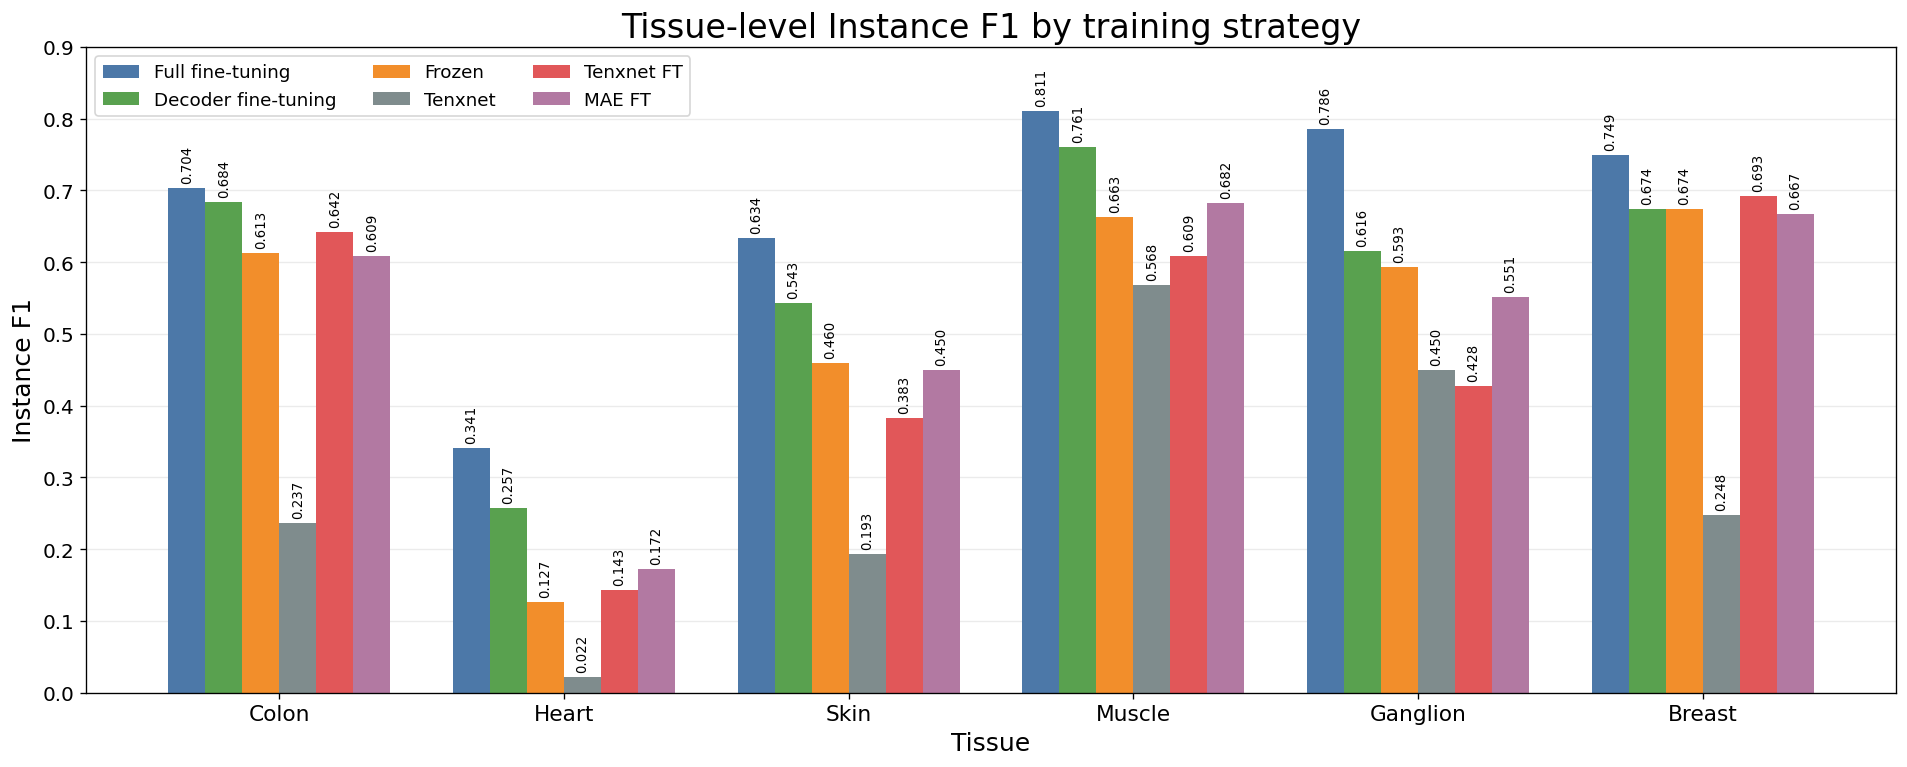

In [ ]:
tissue_labels = ["Colon", "Heart", "Skin", "Muscle", "Ganglion", "Breast"]
tissue_f1_results = {
    "Full fine-tuning": np.array([0.704, 0.341, 0.634, 0.811, 0.786, 0.749]),
    "Decoder fine-tuning": np.array([0.684, 0.257, 0.543, 0.761, 0.616, 0.674]),
    "Frozen": np.array([0.613, 0.127, 0.460, 0.663, 0.593, 0.674]),
    "Tenxnet": np.array([0.237, 0.022, 0.193, 0.568, 0.450, 0.248]),
    "Tenxnet FT": np.array([0.642, 0.143, 0.383, 0.609, 0.428, 0.693]),
    "MAE FT": np.array([0.609, 0.172, 0.450, 0.682, 0.551, 0.667]),
}

x_positions = np.arange(len(tissue_labels))
n_methods = len(tissue_f1_results)
bar_width = 0.13
method_colors = ["#4c78a8", "#59a14f", "#f28e2b", "#7f8c8d", "#e15759", "#b279a2"]

fig, ax_tissue_f1 = plt.subplots(figsize=(16, 6.5), dpi=120)
for method_index, ((method, values), color) in enumerate(zip(tissue_f1_results.items(), method_colors)):
    offset = (method_index - (n_methods - 1) / 2) * bar_width
    bars = ax_tissue_f1.bar(
        x_positions + offset, values, width=bar_width,
        label=method, color=color,
    )
    ax_tissue_f1.bar_label(
        bars, labels=[f"{value:.3f}" for value in values],
        padding=3, fontsize=8, rotation=90,
    )

ax_tissue_f1.set_title("Tissue-level Instance F1 by training strategy", fontsize=20)
ax_tissue_f1.set_xlabel("Tissue", fontsize=15)
ax_tissue_f1.set_ylabel("Instance F1", fontsize=15)
ax_tissue_f1.set_xticks(x_positions, tissue_labels)
ax_tissue_f1.set_ylim(0, 0.9)
ax_tissue_f1.grid(axis="y", alpha=0.25)
ax_tissue_f1.set_axisbelow(True)
ax_tissue_f1.tick_params(axis="x", labelsize=13)
ax_tissue_f1.tick_params(axis="y", labelsize=12)
ax_tissue_f1.legend(fontsize=11, ncol=3, loc="upper left")
fig.tight_layout()
plt.show()

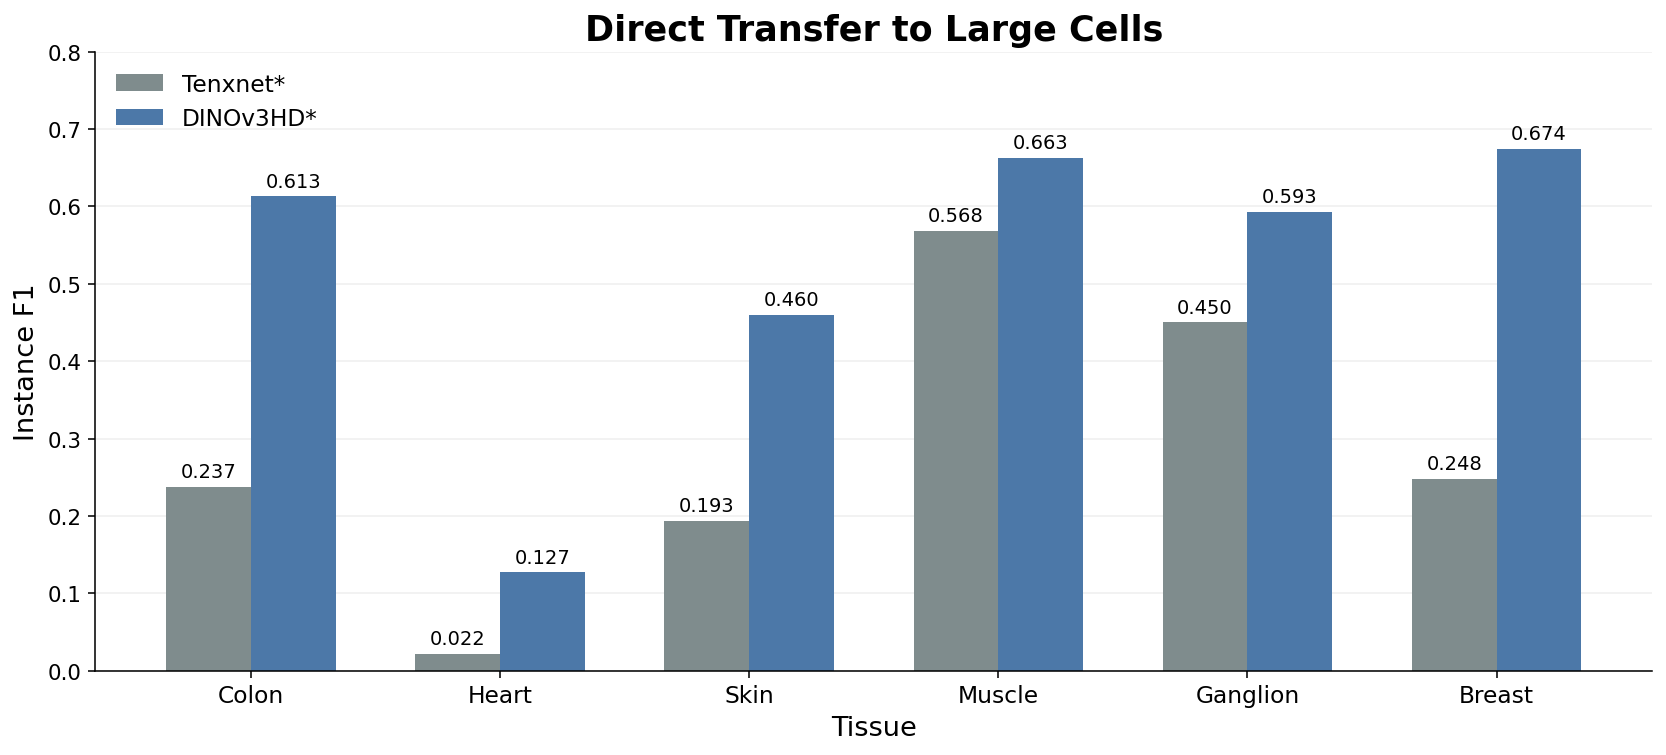

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

tissue_labels = ["Colon", "Heart", "Skin", "Muscle", "Ganglion", "Breast"]

# Direct transfer:
# both models are trained on normal cells only,
# then evaluated directly on large cells
dino_direct = np.array([0.613, 0.127, 0.460, 0.663, 0.593, 0.674])
tenxnet_direct = np.array([0.237, 0.022, 0.193, 0.568, 0.450, 0.248])

x = np.arange(len(tissue_labels))
bar_width = 0.34

fig, ax = plt.subplots(figsize=(12, 5.5), dpi=140)

# TenxNet
bars_tenx = ax.bar(
    x - bar_width / 2,
    tenxnet_direct,
    width=bar_width,
    label="Tenxnet*",
    color="#7f8c8d",
)

# DINOv3 + HR
bars_dino = ax.bar(
    x + bar_width / 2,
    dino_direct,
    width=bar_width,
    label="DINOv3HD*",
    color="#4c78a8",
)

# Value labels
ax.bar_label(
    bars_tenx,
    labels=[f"{v:.3f}" for v in tenxnet_direct],
    padding=3,
    fontsize=10,
)

ax.bar_label(
    bars_dino,
    labels=[f"{v:.3f}" for v in dino_direct],
    padding=3,
    fontsize=10,
)

ax.set_title(
    "Direct Transfer to Large Cells",
    fontsize=18,
    fontweight="bold",
)

ax.set_ylabel("Instance F1", fontsize=14)
ax.set_xlabel("Tissue", fontsize=14)

ax.set_xticks(x)
ax.set_xticklabels(tissue_labels, fontsize=12)

ax.set_ylim(0, 0.8)

ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

ax.tick_params(axis="y", labelsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=12,
    loc="upper left",
)

fig.tight_layout()

plt.show()

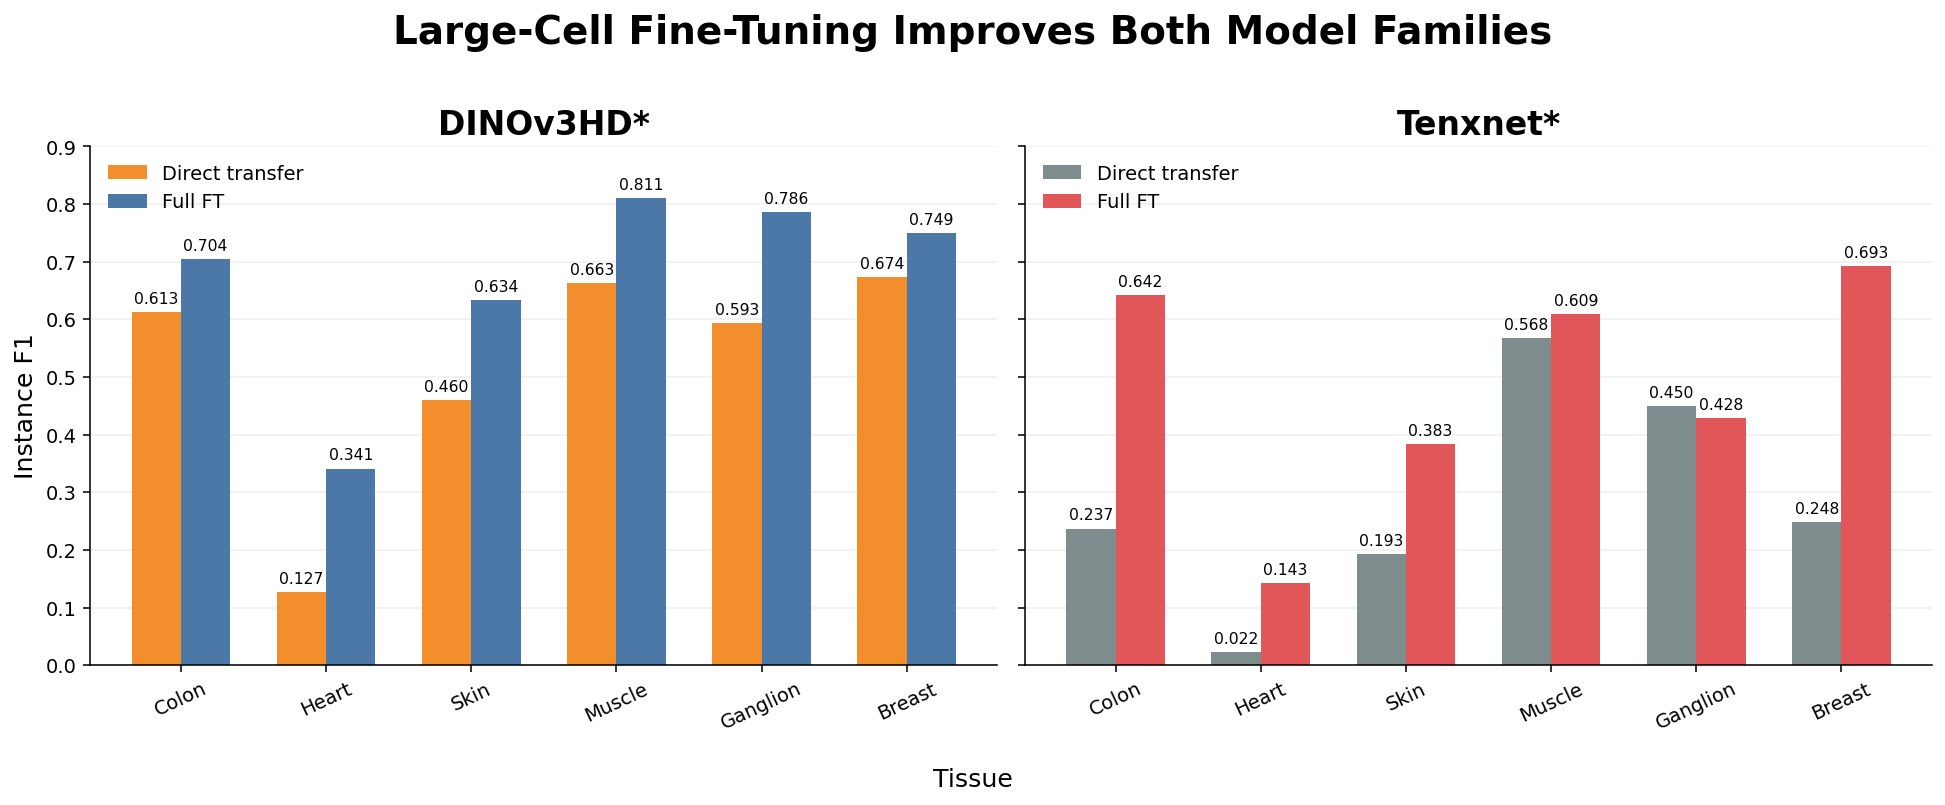

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

tissue_labels = ["Colon", "Heart", "Skin", "Muscle", "Ganglion", "Breast"]

# DINOv3 + HR
dino_direct = np.array([0.613, 0.127, 0.460, 0.663, 0.593, 0.674])
dino_ft = np.array([0.704, 0.341, 0.634, 0.811, 0.786, 0.749])

# TenxNet
tenx_direct = np.array([0.237, 0.022, 0.193, 0.568, 0.450, 0.248])
tenx_ft = np.array([0.642, 0.143, 0.383, 0.609, 0.428, 0.693])

x = np.arange(len(tissue_labels))
bar_width = 0.34

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5.5),
    dpi=140,
    sharey=True
)

# ============================================================
# Left: DINOv3 + HR
# ============================================================
ax = axes[0]

bars_direct = ax.bar(
    x - bar_width / 2,
    dino_direct,
    width=bar_width,
    label="Direct transfer",
    color="#f28e2b",   # DINOv3 Frozen / Direct transfer
)

bars_ft = ax.bar(
    x + bar_width / 2,
    dino_ft,
    width=bar_width,
    label="Full FT",
    color="#4c78a8",   # DINOv3 Full FT
)

ax.bar_label(
    bars_direct,
    labels=[f"{v:.3f}" for v in dino_direct],
    padding=3,
    fontsize=8,
    rotation=0,
)

ax.bar_label(
    bars_ft,
    labels=[f"{v:.3f}" for v in dino_ft],
    padding=3,
    fontsize=8,
    rotation=0,
)

ax.set_title(
    "DINOv3HD*",
    fontsize=17,
    fontweight="bold",
)

ax.set_ylabel("Instance F1", fontsize=13)

ax.set_xticks(x)
ax.set_xticklabels(tissue_labels, fontsize=10, rotation=25)

ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper left",
)

# Mean summary
# ax.text(
#     0.97, 0.96,
#     f"Mean F1\n"
#     f"{dino_direct.mean():.3f} → {dino_ft.mean():.3f}\n"
#     f"+{(dino_ft.mean() - dino_direct.mean()):.3f}",
#     transform=ax.transAxes,
#     ha="right",
#     va="top",
#     fontsize=10,
#     bbox=dict(
#         boxstyle="round,pad=0.4",
#         fc="white",
#         ec="#cccccc",
#     ),
# )

# ============================================================
# Right: TenxNet
# ============================================================
ax = axes[1]

bars_direct = ax.bar(
    x - bar_width / 2,
    tenx_direct,
    width=bar_width,
    label="Direct transfer",
    color="#7f8c8d",   # TenxNet Direct transfer
)

bars_ft = ax.bar(
    x + bar_width / 2,
    tenx_ft,
    width=bar_width,
    label="Full FT",
    color="#e15759",   # TenxNet Full FT
)

ax.bar_label(
    bars_direct,
    labels=[f"{v:.3f}" for v in tenx_direct],
    padding=3,
    fontsize=8,
    rotation=0,
)

ax.bar_label(
    bars_ft,
    labels=[f"{v:.3f}" for v in tenx_ft],
    padding=3,
    fontsize=8,
    rotation=0,
)

ax.set_title(
    "Tenxnet*",
    fontsize=17,
    fontweight="bold",
)

ax.set_xticks(x)
ax.set_xticklabels(tissue_labels, fontsize=10, rotation=25)

ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper left",
)

# ax.text(
#     0.97, 0.96,
#     f"Mean F1\n"
#     f"{tenx_direct.mean():.3f} → {tenx_ft.mean():.3f}\n"
#     f"+{(tenx_ft.mean() - tenx_direct.mean()):.3f}",
#     transform=ax.transAxes,
#     ha="right",
#     va="top",
#     fontsize=10,
#     bbox=dict(
#         boxstyle="round,pad=0.4",
#         fc="white",
#         ec="#cccccc",
#     ),
# )

# ============================================================
# Shared styling
# ============================================================
for ax in axes:
    ax.set_ylim(0, 0.9)
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="y", labelsize=10)

fig.suptitle(
    "Large-Cell Fine-Tuning Improves Both Model Families",
    fontsize=20,
    fontweight="bold",
    y=1.02,
)

fig.supxlabel("Tissue", fontsize=13)

fig.tight_layout()
plt.show()

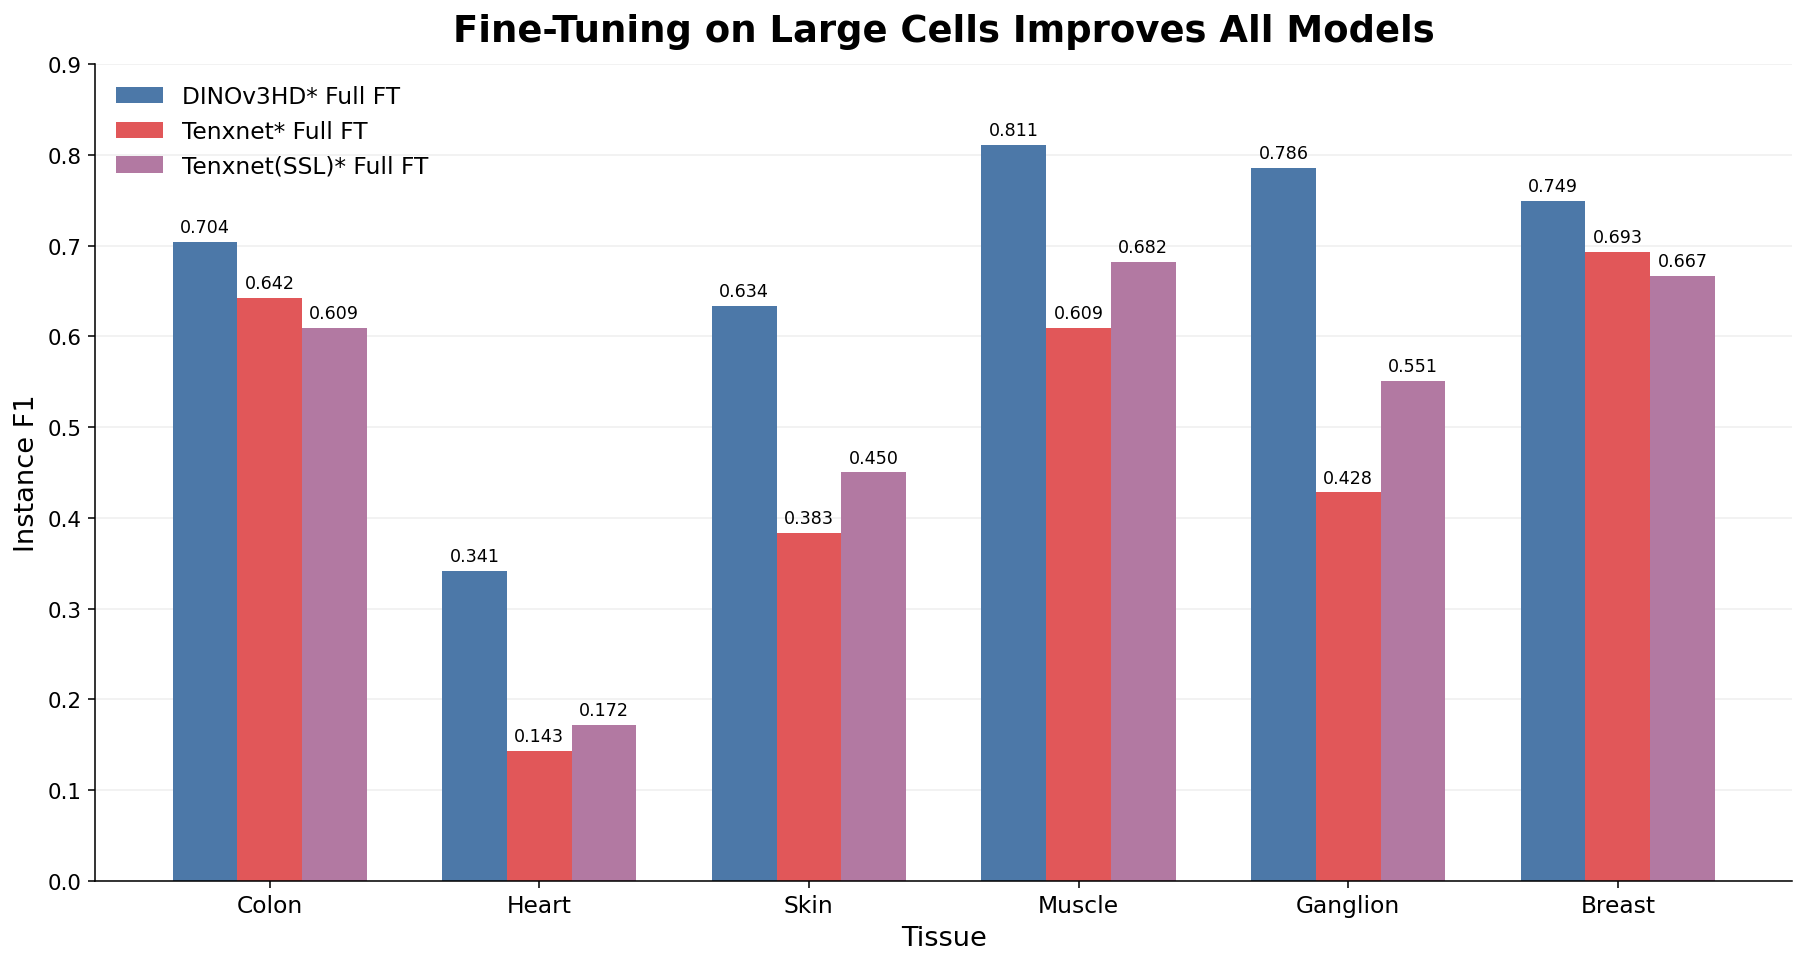

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

tissue_labels = ["Colon", "Heart", "Skin", "Muscle", "Ganglion", "Breast"]

# Fine-tuned results
dino_hr_ft = np.array([0.704, 0.341, 0.634, 0.811, 0.786, 0.749])
tenxnet_ft = np.array([0.642, 0.143, 0.383, 0.609, 0.428, 0.693])
tenxnet_ssl_ft = np.array([0.609, 0.172, 0.450, 0.682, 0.551, 0.667])

x = np.arange(len(tissue_labels))
bar_width = 0.24

fig, ax = plt.subplots(figsize=(13, 7), dpi=140)

# Bars
bars_dino = ax.bar(
    x - bar_width,
    dino_hr_ft,
    width=bar_width,
    label="DINOv3HD* Full FT",
    color="#4c78a8",
)

bars_tenx = ax.bar(
    x,
    tenxnet_ft,
    width=bar_width,
    label="Tenxnet* Full FT",
    color="#e15759",
)

bars_ssl = ax.bar(
    x + bar_width,
    tenxnet_ssl_ft,
    width=bar_width,
    label="Tenxnet(SSL)* Full FT",
    color="#b279a2",
)

# Value labels
ax.bar_label(
    bars_dino,
    labels=[f"{v:.3f}" for v in dino_hr_ft],
    padding=3,
    fontsize=9,
    rotation=0,
)

ax.bar_label(
    bars_tenx,
    labels=[f"{v:.3f}" for v in tenxnet_ft],
    padding=3,
    fontsize=9,
    rotation=0,
)

ax.bar_label(
    bars_ssl,
    labels=[f"{v:.3f}" for v in tenxnet_ssl_ft],
    padding=3,
    fontsize=9,
    rotation=0,
)

# Axes and style
ax.set_title(
    "Fine-Tuning on Large Cells Improves All Models",
    fontsize=19,
    fontweight="bold",
    pad=12,
)
ax.set_ylabel("Instance F1", fontsize=14)
ax.set_xlabel("Tissue", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(tissue_labels, fontsize=12)
ax.set_ylim(0, 0.9)

ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)
ax.tick_params(axis="y", labelsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=12,
    loc="upper left",
)

# Optional: mean F1 summary box
mean_dino = dino_hr_ft.mean()
mean_tenx = tenxnet_ft.mean()
mean_ssl = tenxnet_ssl_ft.mean()

summary_text = (
    f"Mean F1\n"
    f"DINOv3HD* FT: {mean_dino:.3f}\n"
    f"Tenxnet* FT: {mean_tenx:.3f}\n"
    f"Tenxnet(SSL)* FT: {mean_ssl:.3f}"
)

# ax.text(
#     0.985, 0.985,
#     summary_text,
#     transform=ax.transAxes,
#     ha="right",
#     va="top",
#     fontsize=11,
#     bbox=dict(
#         boxstyle="round,pad=0.4",
#         fc="white",
#         ec="#cccccc",
#         lw=1.0,
#     ),
# )

fig.tight_layout()
plt.show()

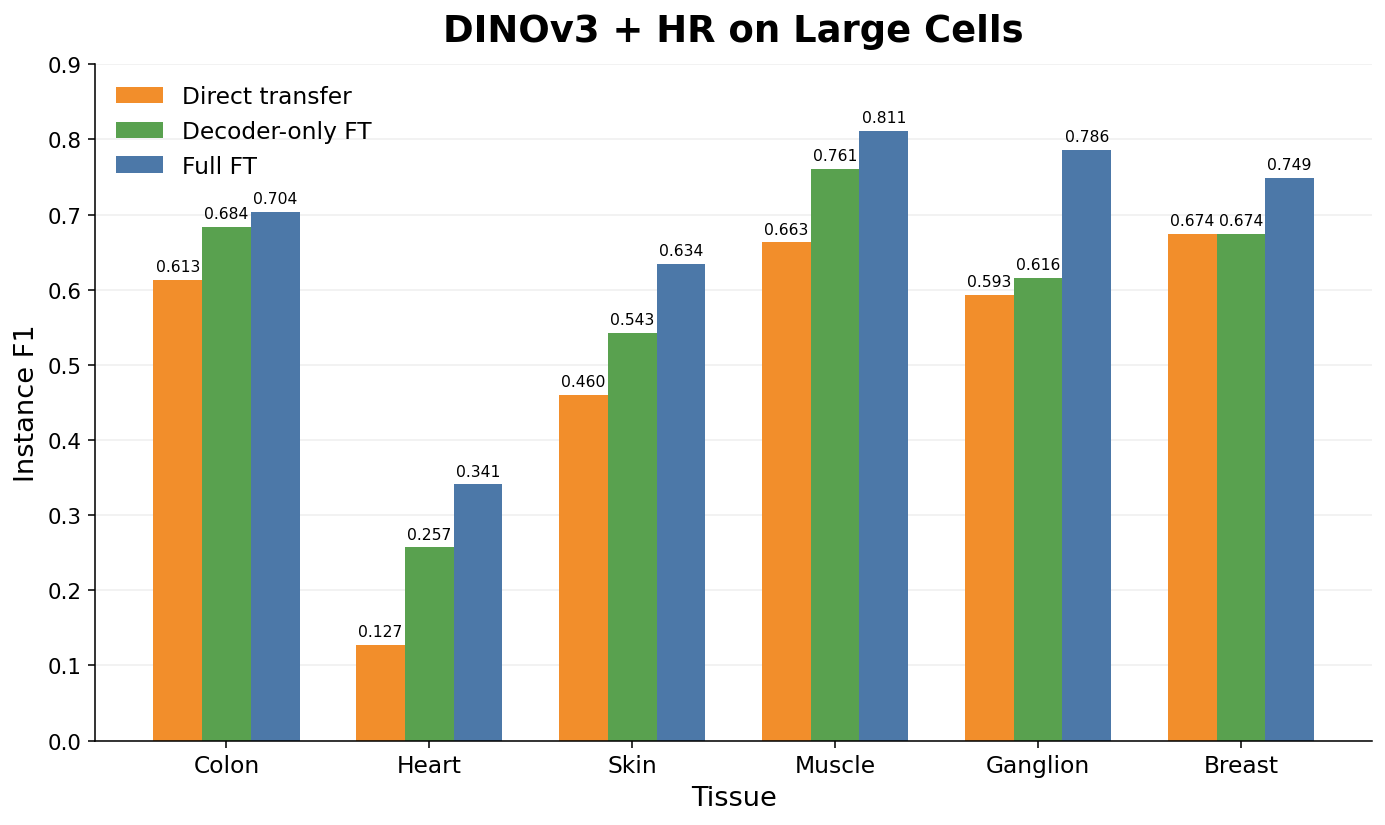

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

tissue_labels = ["Colon", "Heart", "Skin", "Muscle", "Ganglion", "Breast"]

# DINOv3 + HR on large cells
dino_direct = np.array([0.613, 0.127, 0.460, 0.663, 0.593, 0.674])
dino_decoder_ft = np.array([0.684, 0.257, 0.543, 0.761, 0.616, 0.674])
dino_full_ft = np.array([0.704, 0.341, 0.634, 0.811, 0.786, 0.749])

x = np.arange(len(tissue_labels))
bar_width = 0.24

fig, ax = plt.subplots(figsize=(10, 6), dpi=140)

# Bars
bars_direct = ax.bar(
    x - bar_width,
    dino_direct,
    width=bar_width,
    label="Direct transfer",
    color="#f28e2b",
)

bars_decoder = ax.bar(
    x,
    dino_decoder_ft,
    width=bar_width,
    label="Decoder-only FT",
    color="#59a14f",
)

bars_full = ax.bar(
    x + bar_width,
    dino_full_ft,
    width=bar_width,
    label="Full FT",
    color="#4c78a8",
)

# Value labels
ax.bar_label(
    bars_direct,
    labels=[f"{v:.3f}" for v in dino_direct],
    padding=3,
    fontsize=8,
    rotation=0,
)

ax.bar_label(
    bars_decoder,
    labels=[f"{v:.3f}" for v in dino_decoder_ft],
    padding=3,
    fontsize=8,
    rotation=0,
)

ax.bar_label(
    bars_full,
    labels=[f"{v:.3f}" for v in dino_full_ft],
    padding=3,
    fontsize=8,
    rotation=0,
)

# Titles and labels
ax.set_title(
    "DINOv3 + HR on Large Cells",
    fontsize=19,
    fontweight="bold",
    pad=12,
)
ax.set_ylabel("Instance F1", fontsize=14)
ax.set_xlabel("Tissue", fontsize=14)

ax.set_xticks(x)
ax.set_xticklabels(tissue_labels, fontsize=12)

ax.set_ylim(0, 0.9)

# Style
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)
ax.tick_params(axis="y", labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=12,
    loc="upper left",
)

# Mean F1 summary box
mean_direct = dino_direct.mean()
mean_decoder = dino_decoder_ft.mean()
mean_full = dino_full_ft.mean()

summary_text = (
    f"Mean F1\n"
    f"Direct transfer: {mean_direct:.3f}\n"
    f"Decoder-only FT: {mean_decoder:.3f}\n"
    f"Full FT: {mean_full:.3f}"
)

# ax.text(
#     0.985, 0.985,
#     summary_text,
#     transform=ax.transAxes,
#     ha="right",
#     va="top",
#     fontsize=11,
#     bbox=dict(
#         boxstyle="round,pad=0.4",
#         fc="white",
#         ec="#cccccc",
#         lw=1.0,
#     ),
# )

fig.tight_layout()
plt.show()

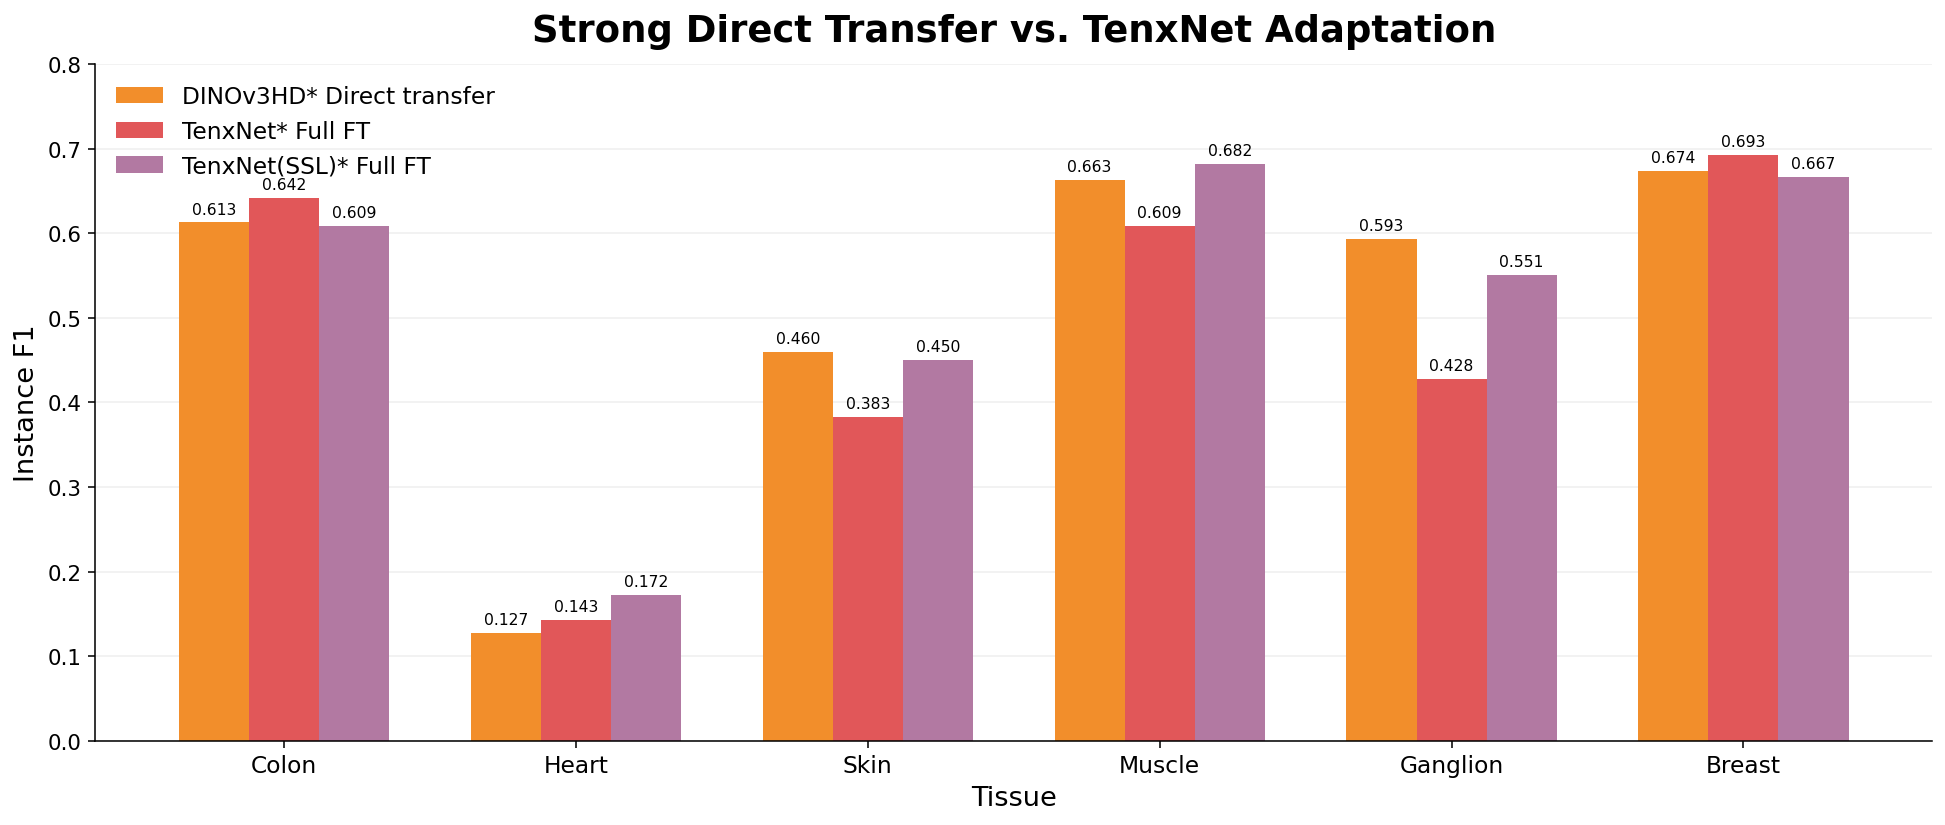

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

tissue_labels = ["Colon", "Heart", "Skin", "Muscle", "Ganglion", "Breast"]

# DINOv3 + HR direct transfer (formerly "Frozen")
dino_direct = np.array([0.613, 0.127, 0.460, 0.663, 0.593, 0.674])

# TenxNet family full fine-tuning
tenxnet_ft = np.array([0.642, 0.143, 0.383, 0.609, 0.428, 0.693])
tenxnet_ssl_ft = np.array([0.609, 0.172, 0.450, 0.682, 0.551, 0.667])

x = np.arange(len(tissue_labels))
bar_width = 0.24

fig, ax = plt.subplots(figsize=(14, 6), dpi=140)

# Bars
bars_dino = ax.bar(
    x - bar_width,
    dino_direct,
    width=bar_width,
    label="DINOv3HD* Direct transfer",
    color="#f28e2b",
)

bars_tenx = ax.bar(
    x,
    tenxnet_ft,
    width=bar_width,
    label="TenxNet* Full FT",
    color="#e15759",
)

bars_ssl = ax.bar(
    x + bar_width,
    tenxnet_ssl_ft,
    width=bar_width,
    label="TenxNet(SSL)* Full FT",
    color="#b279a2",
)

# Value labels
ax.bar_label(
    bars_dino,
    labels=[f"{v:.3f}" for v in dino_direct],
    padding=3,
    fontsize=8,
    rotation=0,
)

ax.bar_label(
    bars_tenx,
    labels=[f"{v:.3f}" for v in tenxnet_ft],
    padding=3,
    fontsize=8,
    rotation=0,
)

ax.bar_label(
    bars_ssl,
    labels=[f"{v:.3f}" for v in tenxnet_ssl_ft],
    padding=3,
    fontsize=8,
    rotation=0,
)

# Titles and labels
ax.set_title(
    "Strong Direct Transfer vs. TenxNet Adaptation",
    fontsize=19,
    fontweight="bold",
    pad=12,
)
ax.set_ylabel("Instance F1", fontsize=14)
ax.set_xlabel("Tissue", fontsize=14)

ax.set_xticks(x)
ax.set_xticklabels(tissue_labels, fontsize=12)
ax.set_ylim(0, 0.8)

# Style
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)
ax.tick_params(axis="y", labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=12,
    loc="upper left",
)

# Mean F1 summary
mean_dino = dino_direct.mean()
mean_tenx = tenxnet_ft.mean()
mean_ssl = tenxnet_ssl_ft.mean()

summary_text = (
    f"Mean F1\n"
    f"DINOv3 + HR Direct: {mean_dino:.3f}\n"
    f"TenxNet FT: {mean_tenx:.3f}\n"
    f"TenxNet + SSL FT: {mean_ssl:.3f}"
)



fig.tight_layout()
plt.show()

## Tissue fine-tuning validation curves

For each `convnext_dino_hires_{tissue}` and `tenxnet_recipe_spark_{tissue}` log, this section detects epoch resets and uses only the final training run. Both model families are restricted to logged epochs 0–199 (the first 200 epochs) for a direct comparison.

DINOv3HD*:
  colon: final of 2 runs; final run=200 epochs; plotted=200; best=0.5448 @ 16
  heart: final of 2 runs; final run=200 epochs; plotted=200; best=2.1463 @ 14
  skin: final of 4 runs; final run=200 epochs; plotted=200; best=0.8626 @ 12
  muscle: final of 5 runs; final run=300 epochs; plotted=200; best=0.9175 @ 55
  ganglion: final of 2 runs; final run=200 epochs; plotted=200; best=0.4437 @ 19
  breast: final of 5 runs; final run=200 epochs; plotted=200; best=1.1382 @ 57
Tenxnet(SSL)*:
  colon: final of 1 runs; final run=200 epochs; plotted=200; best=0.4517 @ 124
  heart: final of 1 runs; final run=200 epochs; plotted=200; best=2.5297 @ 199
  skin: final of 1 runs; final run=200 epochs; plotted=200; best=0.9222 @ 192
  muscle: final of 1 runs; final run=200 epochs; plotted=200; best=1.2627 @ 73
  ganglion: final of 1 runs; final run=200 epochs; plotted=200; best=0.4763 @ 102
  breast: final of 2 runs; final run=300 epochs; plotted=200; best=1.2676 @ 199


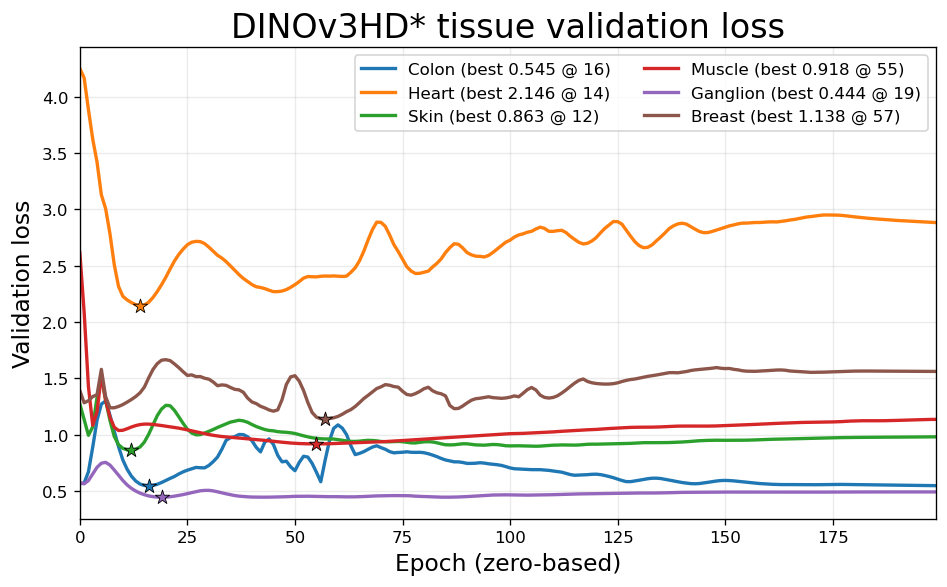

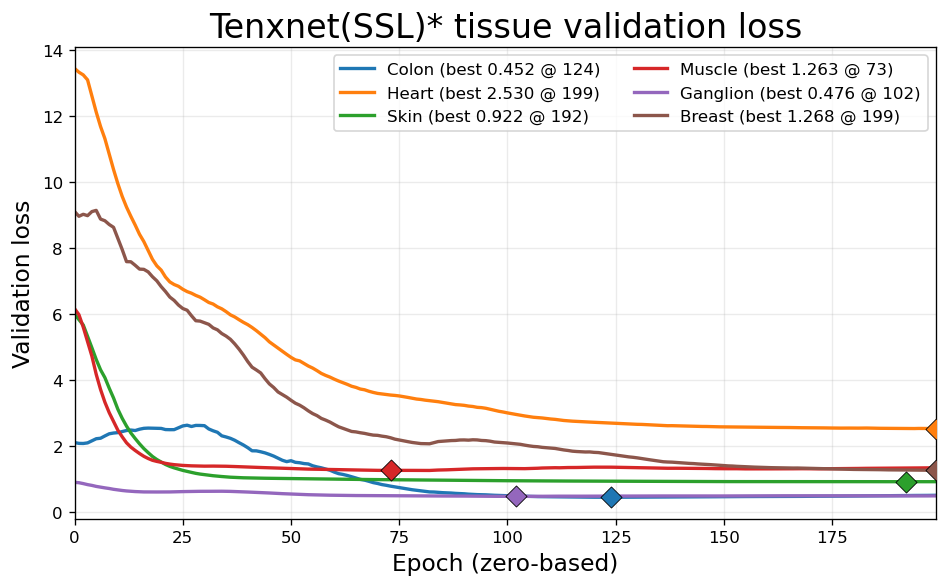

In [10]:
TISSUE_NAMES = ("colon", "heart", "skin", "muscle", "ganglion", "breast")
DINO_TISSUE_RUNS = {
    tissue: PROJECT_ROOT / "runs" / f"convnext_dino_hires_{tissue}"
    for tissue in TISSUE_NAMES
}
SPARK_TISSUE_RUNS = {
    tissue: PROJECT_ROOT / "runs" / f"tenxnet_recipe_spark_{tissue}"
    for tissue in TISSUE_NAMES
}
MAX_TISSUE_EPOCHS = 200


def load_last_training_val_curve(log_path, max_epochs=200):
    """Use the final zero-based training segment in an appended JSONL log."""
    segments = []
    current_segment = []

    with log_path.open() as handle:
        for line in handle:
            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                continue
            if "epoch" not in record or "val_loss" not in record:
                continue

            epoch = int(record["epoch"])
            if epoch == 0 and current_segment:
                segments.append(current_segment)
                current_segment = []
            current_segment.append((epoch, float(record["val_loss"])))

    if current_segment:
        segments.append(current_segment)
    if not segments:
        raise ValueError(f"No validation-loss records found in {log_path}")

    final_segment = segments[-1]
    # The last record wins if an epoch was logged more than once within the final run.
    loss_by_epoch = {epoch: loss for epoch, loss in final_segment if epoch < max_epochs}
    epochs = np.array(sorted(loss_by_epoch), dtype=int)
    losses = np.array([loss_by_epoch[epoch] for epoch in epochs], dtype=float)
    return epochs, losses, len(segments), len(final_segment)


def load_tissue_curve_group(run_dirs, family_name):
    curves = {}
    print(f"{family_name}:")
    for tissue, run_dir in run_dirs.items():
        curve = load_last_training_val_curve(run_dir / "log.txt", MAX_TISSUE_EPOCHS)
        curves[tissue] = curve
        epochs, losses, run_count, final_run_length = curve
        best_index = int(np.argmin(losses))
        print(
            f"  {tissue}: final of {run_count} runs; final run={final_run_length} epochs; "
            f"plotted={len(epochs)}; best={losses[best_index]:.4f} @ {epochs[best_index]}"
        )
    return curves


dino_tissue_val_curves = load_tissue_curve_group(DINO_TISSUE_RUNS, "DINOv3HD*")
spark_tissue_val_curves = load_tissue_curve_group(SPARK_TISSUE_RUNS, "Tenxnet(SSL)*")

tissue_colors = dict(zip(TISSUE_NAMES, plt.cm.tab10(np.arange(len(TISSUE_NAMES)))))


def plot_tissue_curve_figure(curves, title, best_marker):
    fig, axis = plt.subplots(figsize=(8, 5), dpi=120)
    for tissue in TISSUE_NAMES:
        epochs, losses, _, _ = curves[tissue]
        best_index = int(np.argmin(losses))
        color = tissue_colors[tissue]
        axis.plot(
            epochs, losses, color=color, linewidth=2,
            label=f"{tissue.title()} (best {losses[best_index]:.3f} @ {epochs[best_index]})",
        )
        axis.scatter(
            epochs[best_index], losses[best_index],
            marker=best_marker, s=80, color=color,
            edgecolor="black", linewidth=0.5, zorder=3,
        )

    axis.set_title(title, fontsize=20)
    axis.set_xlabel("Epoch (zero-based)", fontsize=14)
    axis.set_ylabel("Validation loss", fontsize=14)
    axis.set_xlim(0, MAX_TISSUE_EPOCHS - 1)
    axis.grid(alpha=0.25)
    axis.legend(fontsize=10, ncol=2)
    fig.tight_layout()
    return fig, axis


dino_tissue_fig, ax_dino_tissue_curves = plot_tissue_curve_figure(
    dino_tissue_val_curves, "DINOv3HD* tissue validation loss", best_marker="*",
)
plt.show()

spark_tissue_fig, ax_spark_tissue_curves = plot_tissue_curve_figure(
    spark_tissue_val_curves, "Tenxnet(SSL)* tissue validation loss", best_marker="D",
)
plt.show()

Strict order: DINOv3+HR > DINOv3+HR frozen > TenxNet-recipe SPARK > TenxNet-recipe
Only GT-positive images are used for F1 ordering.


,Tissue,Common images,GT-positive images,Strict order,Strict order (%),Order allowing ties,Allowing ties (%)
0,Colon,107,30,1,3.3,1,3.3
1,Heart,69,68,23,33.8,26,38.2
2,Skin,68,43,10,23.3,11,25.6
3,Muscle,68,66,22,33.3,30,45.5
4,Ganglion,76,62,24,38.7,32,51.6
5,Breast,33,25,1,4.0,1,4.0
6,Total,421,294,81,27.6,101,34.4


Largest top-to-bottom F1 gap among strictly ordered images in each tissue:


,Tissue,Image key,Image path,Top-bottom gap,DINOv3+HR F1,Frozen F1,SPARK F1,TenxNet F1,DINO-Frozen gap,Frozen-SPARK gap,SPARK-TenxNet gap
0,Colon,boundary_large_cells__hu_colon_1641254_1707068_x_42942_y_4919_s_0.25,/mnt/home/ruizhi.yuan/data/large_cell_boundary/large_cell_boundary/images/boundary_large_cells/h...,0.363,0.927,0.623,0.618,0.563,0.303,0.006,0.054
1,Heart,boundary_large_cells_v2__ms_heart_1694429_1765059_x_7451_y_8770_s_0.25,/mnt/home/ruizhi.yuan/data/large_cell_boundary/large_cell_boundary/images/boundary_large_cells_v...,0.348,0.492,0.286,0.250,0.144,0.206,0.036,0.106
2,Skin,boundary_large_cells__hu_skin_1596847_1665757_x_4737_y_24231_s_0.25,/mnt/home/ruizhi.yuan/data/large_cell_boundary/large_cell_boundary/images/boundary_large_cells/h...,0.466,0.729,0.682,0.330,0.263,0.047,0.352,0.067
3,Muscle,boundary_large_cells_v2__hu_muscle_xetg00232_0025295_x_15193_y_41440_s_0.25,/mnt/home/ruizhi.yuan/data/large_cell_boundary/large_cell_boundary/images/boundary_large_cells_v...,0.947,0.947,0.778,0.600,0.000,0.170,0.178,0.600
4,Ganglion,boundary_large_cells_v3__dg_ganglion_cs_ro4530_x_35196_y_15492_s_0.25,/mnt/home/ruizhi.yuan/data/large_cell_boundary/large_cell_boundary/images/boundary_large_cells_v...,0.806,0.939,0.725,0.411,0.133,0.214,0.314,0.278
5,Breast,boundary_large_cells_v2__hu_breast_1583096_1643209_x_22206_y_34463_s_0.25,/mnt/home/ruizhi.yuan/data/large_cell_boundary/large_cell_boundary/images/boundary_large_cells_v...,0.355,0.784,0.614,0.512,0.429,0.170,0.102,0.083


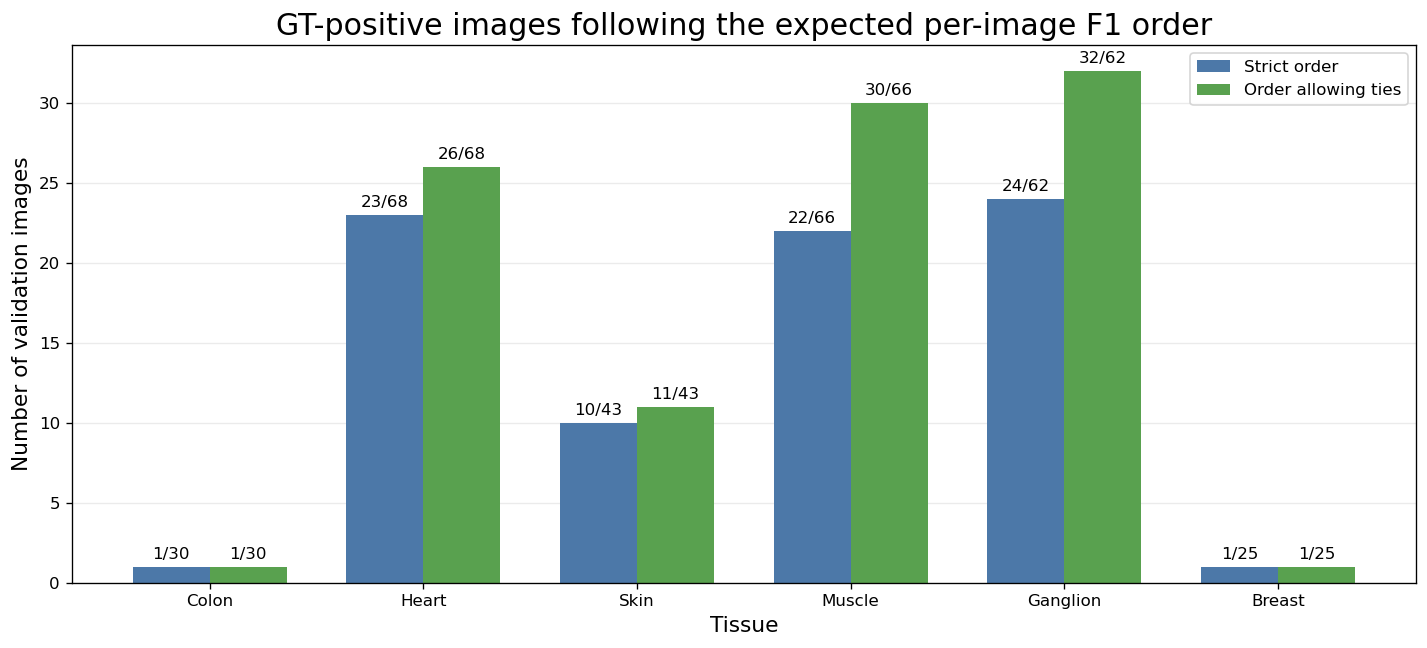

In [ ]:
# Per-image paired F1 ordering analysis across the four tissue-specific models.
import csv

import pandas as pd
from IPython.display import display

ORDER_TISSUES = ("colon", "heart", "skin", "muscle", "ganglion", "breast")
ORDER_MODELS = [
    ("DINOv3+HR", "convnext_dino_hires_{}"),
    ("DINOv3+HR frozen", "convnext_dino_hires_frozen_{}"),
    ("TenxNet-recipe SPARK", "tenxnet_recipe_spark_{}"),
    ("TenxNet-recipe", "tenxnet_recipe_{}"),
]


def per_image_instance_f1(metrics):
    denominator = (
        2 * metrics["true_positive"]
        + metrics["false_positive"]
        + metrics["false_negative"]
    )
    return 2 * metrics["true_positive"] / denominator if denominator else np.nan


order_summary_rows = []
largest_gap_rows = []
per_image_order_rows = []

for tissue in ORDER_TISSUES:
    model_metrics = {}
    for model_name, run_pattern in ORDER_MODELS:
        detail_path = (
            PROJECT_ROOT / "runs" / run_pattern.format(tissue)
            / "turing_val" / "turing_detailed.json"
        )
        with detail_path.open() as handle:
            model_metrics[model_name] = json.load(handle)

    common_keys = set.intersection(*(set(metrics) for metrics in model_metrics.values()))
    reference_model = ORDER_MODELS[0][0]
    positive_keys = sorted(
        key for key in common_keys
        if model_metrics[reference_model][key]["n_gt"] > 0
    )

    reference_manifest = (
        PROJECT_ROOT / "runs" / ORDER_MODELS[0][1].format(tissue)
        / "turing_val" / "export_manifest.csv"
    )
    with reference_manifest.open(newline="") as handle:
        manifest_by_key = {row["key"]: row for row in csv.DictReader(handle)}

    tissue_rows = []
    for key in positive_keys:
        scores = {
            model_name: per_image_instance_f1(model_metrics[model_name][key])
            for model_name, _ in ORDER_MODELS
        }
        ordered_scores = [scores[model_name] for model_name, _ in ORDER_MODELS]
        strict_order = all(left > right for left, right in zip(ordered_scores, ordered_scores[1:]))
        nonincreasing_order = all(
            left >= right for left, right in zip(ordered_scores, ordered_scores[1:])
        )
        row = {
            "tissue": tissue.title(),
            "image_key": key,
            **scores,
            "strict_order": strict_order,
            "order_allowing_ties": nonincreasing_order,
        }
        tissue_rows.append(row)
        per_image_order_rows.append(row)

    strict_rows = [row for row in tissue_rows if row["strict_order"]]
    tied_rows = [row for row in tissue_rows if row["order_allowing_ties"]]
    n_positive = len(positive_keys)
    order_summary_rows.append({
        "Tissue": tissue.title(),
        "Common images": len(common_keys),
        "GT-positive images": n_positive,
        "Strict order": len(strict_rows),
        "Strict order (%)": 100 * len(strict_rows) / n_positive if n_positive else np.nan,
        "Order allowing ties": len(tied_rows),
        "Allowing ties (%)": 100 * len(tied_rows) / n_positive if n_positive else np.nan,
    })

    if strict_rows:
        top_name = ORDER_MODELS[0][0]
        bottom_name = ORDER_MODELS[-1][0]
        largest_gap_row = max(strict_rows, key=lambda row: row[top_name] - row[bottom_name])
        key = largest_gap_row["image_key"]
        label_path = manifest_by_key[key]["label_pb_path"]
        image_path = str(Path(label_path.replace("/labels/", "/images/")).with_suffix(".tif"))
        largest_gap_rows.append({
            "Tissue": tissue.title(),
            "Image key": key,
            "Image path": image_path,
            "Top-bottom gap": largest_gap_row[top_name] - largest_gap_row[bottom_name],
            "DINOv3+HR F1": largest_gap_row["DINOv3+HR"],
            "Frozen F1": largest_gap_row["DINOv3+HR frozen"],
            "SPARK F1": largest_gap_row["TenxNet-recipe SPARK"],
            "TenxNet F1": largest_gap_row["TenxNet-recipe"],
            "DINO-Frozen gap": largest_gap_row["DINOv3+HR"] - largest_gap_row["DINOv3+HR frozen"],
            "Frozen-SPARK gap": largest_gap_row["DINOv3+HR frozen"] - largest_gap_row["TenxNet-recipe SPARK"],
            "SPARK-TenxNet gap": largest_gap_row["TenxNet-recipe SPARK"] - largest_gap_row["TenxNet-recipe"],
        })

order_summary = pd.DataFrame(order_summary_rows)
total_positive = int(order_summary["GT-positive images"].sum())
order_summary = pd.concat([
    order_summary,
    pd.DataFrame([{
        "Tissue": "Total",
        "Common images": int(order_summary["Common images"].sum()),
        "GT-positive images": total_positive,
        "Strict order": int(order_summary["Strict order"].sum()),
        "Strict order (%)": 100 * order_summary["Strict order"].sum() / total_positive,
        "Order allowing ties": int(order_summary["Order allowing ties"].sum()),
        "Allowing ties (%)": 100 * order_summary["Order allowing ties"].sum() / total_positive,
    }]),
], ignore_index=True)
largest_f1_gap_by_tissue = pd.DataFrame(largest_gap_rows)
per_image_f1_order = pd.DataFrame(per_image_order_rows)

print("Strict order: DINOv3+HR > DINOv3+HR frozen > TenxNet-recipe SPARK > TenxNet-recipe")
print("Only GT-positive images are used for F1 ordering.")
display(order_summary.round({"Strict order (%)": 1, "Allowing ties (%)": 1}))

print("Largest top-to-bottom F1 gap among strictly ordered images in each tissue:")
with pd.option_context("display.max_colwidth", 100):
    display(largest_f1_gap_by_tissue.round(3))

plot_summary = order_summary.iloc[:-1]
x = np.arange(len(plot_summary))
width = 0.36
fig, ax_f1_order_counts = plt.subplots(figsize=(12, 5.5), dpi=120)
strict_bars = ax_f1_order_counts.bar(
    x - width / 2, plot_summary["Strict order"], width,
    label="Strict order", color="#4c78a8",
)
tie_bars = ax_f1_order_counts.bar(
    x + width / 2, plot_summary["Order allowing ties"], width,
    label="Order allowing ties", color="#59a14f",
)
ax_f1_order_counts.bar_label(
    strict_bars,
    labels=[f"{count}/{total}" for count, total in zip(plot_summary["Strict order"], plot_summary["GT-positive images"])],
    padding=3, fontsize=10,
)
ax_f1_order_counts.bar_label(
    tie_bars,
    labels=[f"{count}/{total}" for count, total in zip(plot_summary["Order allowing ties"], plot_summary["GT-positive images"])],
    padding=3, fontsize=10,
)
ax_f1_order_counts.set_title("GT-positive images following the expected per-image F1 order", fontsize=18)
ax_f1_order_counts.set_xlabel("Tissue", fontsize=13)
ax_f1_order_counts.set_ylabel("Number of validation images", fontsize=13)
ax_f1_order_counts.set_xticks(x, plot_summary["Tissue"])
ax_f1_order_counts.grid(axis="y", alpha=0.25)
ax_f1_order_counts.set_axisbelow(True)
ax_f1_order_counts.legend()
fig.tight_layout()
plt.show()

In [ ]:
# Eight training examples per tissue: boundary channel and instance ground truth.
import csv

import tifffile

TRAIN_EXAMPLE_MANIFESTS = {
    "Muscle": PROJECT_ROOT / "cache/manifest_muscle_train.csv",
    "Ganglion": PROJECT_ROOT / "cache/manifest_ganglion_train.csv",
}
N_TRAIN_EXAMPLES = 8


def read_training_rows(manifest_path, count=N_TRAIN_EXAMPLES):
    with manifest_path.open(newline="") as handle:
        rows = list(csv.DictReader(handle))

    available = [
        row for row in rows
        if Path(row["image_path"]).is_file() and Path(row["inst_ridge_path"]).is_file()
    ]
    if len(available) < count:
        raise RuntimeError(
            f"{manifest_path.name} has only {len(available)} available image/GT pairs; "
            f"{count} are required."
        )
    return available[:count]


def load_boundary_for_display(image_path):
    image = tifffile.imread(image_path)
    if image.ndim == 2:
        boundary = image
    elif image.ndim == 3 and image.shape[-1] <= 4:
        boundary = image[..., 0]
    elif image.ndim == 3 and image.shape[0] <= 4:
        boundary = image[0]
    else:
        raise ValueError(f"Unexpected image shape {image.shape} for {image_path}")

    boundary = boundary.astype(np.float32)
    low, high = np.percentile(boundary, (1, 99))
    if high <= low:
        return np.zeros_like(boundary, dtype=np.float32)
    return np.clip((boundary - low) / (high - low), 0, 1)


def load_instance_gt(inst_ridge_path):
    inst_ridge = np.load(inst_ridge_path, allow_pickle=False)
    if inst_ridge.ndim == 2:
        return inst_ridge
    if inst_ridge.ndim == 3 and inst_ridge.shape[-1] <= 4:
        return inst_ridge[..., 0]
    if inst_ridge.ndim == 3 and inst_ridge.shape[0] <= 4:
        return inst_ridge[0]
    raise ValueError(f"Unexpected GT shape {inst_ridge.shape} for {inst_ridge_path}")


def colorize_instances(instance_gt, seed):
    labels = np.unique(instance_gt)
    labels = labels[labels > 0]
    rgb = np.zeros((*instance_gt.shape, 3), dtype=np.float32)
    rng = np.random.default_rng(seed)
    colors = rng.uniform(0.25, 1.0, size=(len(labels), 3))
    for label, color in zip(labels, colors):
        rgb[instance_gt == label] = color
    return rgb, len(labels)


def plot_training_examples(tissue, manifest_path):
    rows = read_training_rows(manifest_path)
    fig, axes = plt.subplots(4, 4, figsize=(14, 13), dpi=120)

    for sample_index, row in enumerate(rows):
        grid_row = sample_index // 2
        grid_col = (sample_index % 2) * 2
        boundary = load_boundary_for_display(row["image_path"])
        instance_gt = load_instance_gt(row["inst_ridge_path"])
        gt_rgb, instance_count = colorize_instances(
            instance_gt, seed=1000 * (1 + list(TRAIN_EXAMPLE_MANIFESTS).index(tissue)) + sample_index
        )

        axes[grid_row, grid_col].imshow(boundary, cmap="gray", vmin=0, vmax=1)
        axes[grid_row, grid_col].set_title(
            f"Sample {sample_index + 1}: boundary (Ch0)", fontsize=10
        )
        axes[grid_row, grid_col + 1].imshow(gt_rgb)
        axes[grid_row, grid_col + 1].set_title(
            f"Sample {sample_index + 1}: GT ({instance_count} instances)", fontsize=10
        )
        for axis in axes[grid_row, grid_col:grid_col + 2]:
            axis.axis("off")

    fig.suptitle(
        f"{tissue} training set: boundary image and ground truth",
        fontsize=18, y=1.01,
    )
    fig.tight_layout()
    plt.show()

    display(pd.DataFrame({
        "Sample": np.arange(1, len(rows) + 1),
        "Tissue": tissue,
        "Image": [Path(row["image_path"]).name for row in rows],
        "Source": [row["subdir"] for row in rows],
    }))


for tissue_name, tissue_manifest in TRAIN_EXAMPLE_MANIFESTS.items():
    plot_training_examples(tissue_name, tissue_manifest)